<a href="https://colab.research.google.com/github/Alessandro-json/AI_PostProcessing_Detection/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2 - Joint Detection of AI-Generated Images and Post-Processing Alterations in Real-World Scenarios

# Imports
This section imports the libraries used throughout the notebook.

In [ ]:
import os
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image


# Globals

In this section we define the main paths and global variables used by the notebook.

Keeping these variables in one place makes the notebook easier to modify and reduces the risk of inconsistent paths across different experiments.

In [ ]:
# Choose where the project will be stored in Colab.
WORKDIR = Path('/content')

REPO_URL = 'https://github.com/Alessandro-json/AI_PostProcessing_Detection'

# Repository folder name after git clone.
REPO_DIR = WORKDIR / 'REPO'

# Main paths used by the scripts.
TRAIN_CSV = 'data/splits/train_balanced.csv'
VAL_CSV = 'data/splits/val_balanced.csv'
TEST_CSV = 'data/splits/test_balanced.csv'

IMAGE_ROOT = "/content/data/raw/RRDataset_subset"
CHECKPOINT_NAME = 'best_rgb.pt'
CHECKPOINT_PATH = f'checkpoints/{CHECKPOINT_NAME}'
DEPTH_ROOT = "/content/drive/MyDrive/CV_Project/depth_maps"

DATASET_FILE_ID = "1HJamsAB4Lj90xNjA6tkfIrstHGJqklsI"
DATASET_ZIP_PATH = "/content/RRDataset_subset.zip"

# Training hyperparameters for the first baseline.
EPOCHS = 10
BATCH_SIZE = 32
IMAGE_SIZE = 224
NUM_WORKERS = 2
LEARNING_RATE = 1e-4

# Multi-task loss weights.
LAMBDA_FAKE = 1.0
LAMBDA_TRANSFORM = 1.0


# Repository setup

The project code is stored in a GitHub repository and imported inside Colab.  
If the repository already exists in the working directory, we update it with `git pull`; otherwise, we clone it from GitHub.


In [ ]:
%cd {WORKDIR}

if REPO_DIR.exists():
    %cd {REPO_DIR}
    !git pull
else:
    !git clone {REPO_URL} {REPO_DIR}
    %cd {REPO_DIR}


/content
Cloning into '/content/REPO'...
^C
[Errno 2] No such file or directory: '/content/REPO'
/content


# Install dependencies

The required Python packages are installed from `requirements.txt`.

In [ ]:
!pip install -q -r requirements.txt

# Utils

This section defines helper functions used to inspect the dataset, verify paths, load evaluation metrics, and visualize saved results.

In [ ]:
def show_csv_summary(csv_path):
    """Print a quick summary of one split CSV."""
    path = Path(csv_path)
    if not path.exists():
        print(f'Missing file: {path}')
        return None

    df = pd.read_csv(path)
    print(f'File: {path}')
    print(f'Rows: {len(df)}')
    print('Columns:', list(df.columns))

    if 'fake_label' in df.columns:
        print('\nFake label distribution:')
        print(df['fake_label'].value_counts().sort_index())

    if 'transform_label' in df.columns:
        print('\nTransform label distribution:')
        print(df['transform_label'].value_counts().sort_index())

    if {'fake_label', 'transform_label'}.issubset(df.columns):
        print('\nJoint distribution:')
        print(pd.crosstab(df['transform_label'], df['fake_label'], rownames=['transform'], colnames=['fake']))

    return df


In [ ]:
def show_image_exists_check(df, image_root, n=5):
    """Check whether the first n image paths exist."""
    if df is None:
        return

    root = Path(image_root)
    print(f'Image root: {root}')

    for rel_path in df['image_path'].head(n):
        full_path = root / rel_path
        print(full_path, 'OK' if full_path.exists() else 'MISSING')

In [ ]:
def show_evaluation_outputs(output_dir):
    """
    Show evaluation metrics and confusion matrices saved by evaluate_RGB.py.
    """

    output_dir = Path(output_dir)
    metrics_path = output_dir / "metrics.json"

    if not metrics_path.exists():
        print(f"Metrics file not found: {metrics_path}")
        return

    # Load metrics saved by evaluate_RGB.py.
    with open(metrics_path, "r", encoding="utf-8") as f:
        metrics = json.load(f)

    # Convert metrics dictionary into a readable table.
    rows = []

    for metric_name, value in metrics.items():
        if isinstance(value, dict):
            for sub_metric_name, sub_value in value.items():
                rows.append({
                    "Metric": metric_name,
                    "Group": sub_metric_name,
                    "Value": sub_value,
                })
        else:
            rows.append({
                "Metric": metric_name,
                "Group": "-",
                "Value": value,
            })

    metrics_df = pd.DataFrame(rows)

    # Format numeric values to 4 decimals.
    if not metrics_df.empty:
        metrics_df["Value"] = metrics_df["Value"].apply(
            lambda x: f"{x:.4f}" if isinstance(x, (int, float)) else x
        )

    print("Evaluation metrics")
    display(metrics_df)

    # Show saved confusion matrices as images.
    fake_cm_path = output_dir / "confusion_fake.png"
    transform_cm_path = output_dir / "confusion_transform.png"

    if fake_cm_path.exists():
        print("\nReal/Fake confusion matrix")
        display(Image(filename=str(fake_cm_path)))

    if transform_cm_path.exists():
        print("\nTransformation confusion matrix")
        display(Image(filename=str(transform_cm_path)))

    if not fake_cm_path.exists() and not transform_cm_path.exists():
        print("\nNo confusion matrix images found in this folder.")

In [ ]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


def build_comparison_df(results_dict):
    rows = []

    for model_name, metrics_path in results_dict.items():
        metrics_path = Path(metrics_path)

        if not metrics_path.exists():
            print(f"Missing file: {metrics_path}")
            continue

        with open(metrics_path, "r") as f:
            metrics = json.load(f)

        rows.append({
            "model": model_name,
            "fake_accuracy": metrics.get("fake_accuracy"),
            "fake_f1_macro": metrics.get("fake_f1_macro"),
            "transform_accuracy": metrics.get("transform_accuracy"),
            "transform_f1_macro": metrics.get("transform_f1_macro"),
            "fake_acc_original": metrics.get("fake_accuracy_by_transform", {}).get("original"),
            "fake_acc_transfer": metrics.get("fake_accuracy_by_transform", {}).get("transfer"),
            "fake_acc_redigital": metrics.get("fake_accuracy_by_transform", {}).get("redigital"),
        })

    comparison_df = pd.DataFrame(rows)

    if len(comparison_df) > 0:
        comparison_df = comparison_df.sort_values(
            by=["fake_accuracy", "transform_accuracy"],
            ascending=False,
        )

    return comparison_df


def plot_global_accuracy(comparison_df, title):
    plot_df = comparison_df.set_index("model")

    plot_df[["fake_accuracy", "transform_accuracy"]].plot(
        kind="bar",
        figsize=(12, 5),
    )

    plt.title(title)
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()


def plot_fake_accuracy_by_transformation(comparison_df, title):
    plot_df = comparison_df.set_index("model")

    plot_df[[
        "fake_acc_original",
        "fake_acc_transfer",
        "fake_acc_redigital",
    ]].plot(
        kind="bar",
        figsize=(12, 5),
    )

    plt.title(title)
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()

[SKIP] results/rgb_fake/metrics.json
[SKIP] results/rgb_transform/metrics.json
[SKIP] results/rgb_multitask_1_1/metrics.json
[SKIP] results/rgb_multitask_1_2/metrics.json
[SKIP] results/rgb_multitask_2_1/metrics.json
[SKIP] results/rgb_multitask_learned_weights/metrics.json
[SKIP] results/depth_frequency_1_1/metrics.json
[SKIP] results/depth_frequency_1_2/metrics.json
[SKIP] results/vit_rgb_multitask_1_1/metrics.json
[SKIP] results/vit_rgb_multitask_1_2/metrics.json
[SKIP] results/vit_rgb_multitask_learned/metrics.json
[SKIP] results/vit_depth_freq_multitask_1_1/metrics.json
[SKIP] results/vit_depth_freq_multitask_1_2/metrics.json
=== Comparative Table ResNet vs ViT ===
No result for the comparative table.


FileNotFoundError: [Errno 2] No such file or directory: 'results/resnet_vs_vit_accuracy.png'

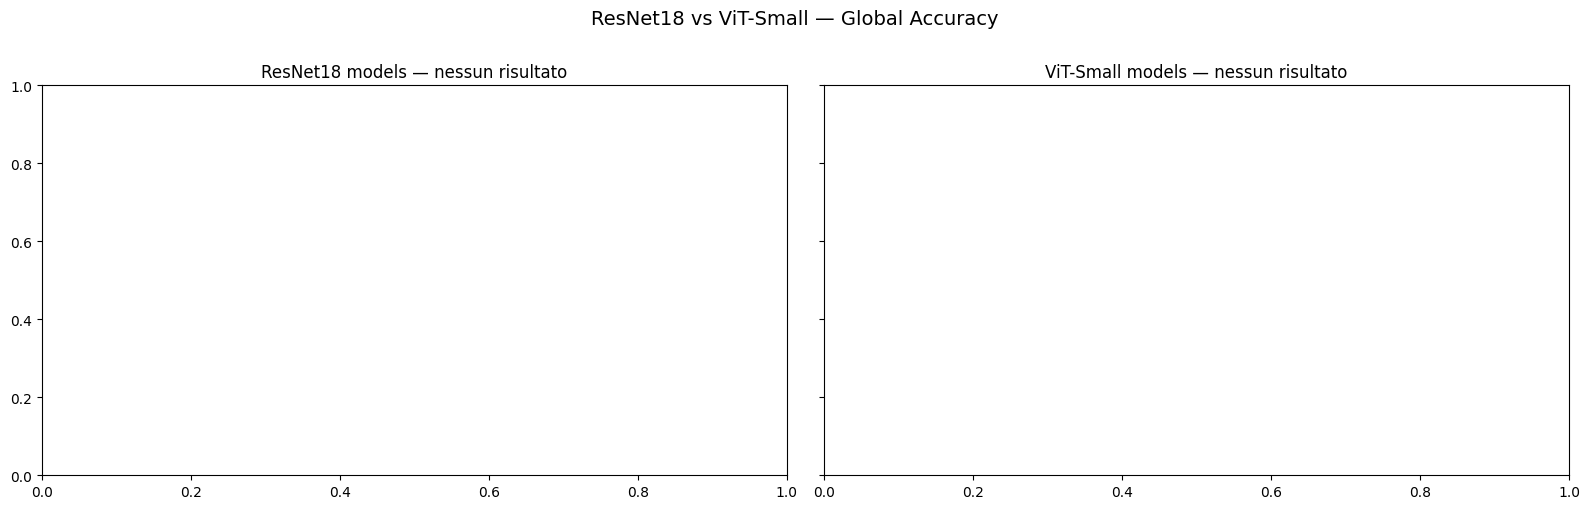

In [ ]:
import json
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from IPython.display import display


def load_results(results_dict):
    rows = []
    for name, path in results_dict.items():
        p = Path(path)
        if not p.exists():
            print(f"[SKIP] {path}")
            continue
        with open(p) as f:
            m = json.load(f)
        by_t = m.get("fake_accuracy_by_transform", {})
        rows.append({
            "model":              name,
            "fake_accuracy":      m.get("fake_accuracy"),
            "transform_accuracy": m.get("transform_accuracy"),
            "fake_f1_macro":      m.get("fake_f1_macro"),
            "transform_f1_macro": m.get("transform_f1_macro"),
            "fake_acc_original":  by_t.get("original"),
            "fake_acc_transfer":  by_t.get("transfer"),
            "fake_acc_redigital": by_t.get("redigital"),
        })
    return pd.DataFrame(rows)


def compare_resnet_vs_vit(resnet_results: dict, vit_results: dict):
    """
    Builds the comparison table and plots between ResNet and ViT models.

    Args:
        resnet_results: dict {model_name: metrics_json_path} for ResNet models.
        vit_results:    dict {model_name: metrics_json_path} for ViT models.
    """

    resnet_df = load_results(resnet_results)
    vit_df    = load_results(vit_results)
    all_df    = pd.concat([resnet_df, vit_df], ignore_index=True)

    display_df = all_df.copy()
    for col in ["fake_accuracy", "transform_accuracy", "fake_f1_macro", "transform_f1_macro"]:
        if col in display_df.columns:
            display_df[col] = display_df[col].apply(
                lambda x: f"{x:.4f}" if pd.notna(x) else "-"
            )

    print("=== Comparative Table ResNet vs ViT ===")
    if display_df.empty:
        print("No results available yet.")
    else:
        display(display_df[["model", "fake_accuracy", "transform_accuracy",
                             "fake_f1_macro", "transform_f1_macro"]])

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

    for ax, df, title, color_fake, color_transform in zip(
        axes,
        [resnet_df, vit_df],
        ["ResNet18 models", "ViT-Small models"],
        ["steelblue", "mediumpurple"],
        ["coral",     "tomato"],
    ):
        if df.empty:
            ax.set_title(f"{title} — No results")
            continue

        x     = range(len(df))
        width = 0.35

        ax.bar([i - width/2 for i in x], df["fake_accuracy"],
               width=width, label="Fake accuracy", color=color_fake, alpha=0.85)
        ax.bar([i + width/2 for i in x], df["transform_accuracy"],
               width=width, label="Transform accuracy", color=color_transform, alpha=0.85)

        ax.set_xticks(list(x))
        ax.set_xticklabels(df["model"], rotation=35, ha="right", fontsize=8)
        ax.set_ylim(0, 1.08)
        ax.set_ylabel("Accuracy")
        ax.set_title(title, fontsize=12)
        ax.legend(loc="lower right")
        ax.grid(axis="y", alpha=0.35)
        ax.axhline(y=0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)

    fig.suptitle("ResNet18 vs ViT-Small — Global Accuracy", fontsize=14, y=1.01)
    plt.tight_layout()
    Path("results").mkdir(exist_ok=True)
    plt.savefig("results/resnet_vs_vit_accuracy.png", dpi=200, bbox_inches="tight")
    plt.show()

    transform_cols = ["fake_acc_original", "fake_acc_transfer", "fake_acc_redigital"]
    labels         = ["Original", "Transfer", "Re-digital"]
    colors         = ["#4c72b0", "#55a868", "#c44e52"]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

    for ax, df, title in zip(
        axes,
        [resnet_df, vit_df],
        ["ResNet18 — Fake Acc by Transform", "ViT-Small — Fake Acc by Transform"],
    ):
        if df.empty:
            ax.set_title(f"{title} — No results")
            continue

        sub = df.dropna(subset=transform_cols, how="all")
        if sub.empty:
            ax.set_title(f"{title} — No results")
            continue

        x     = range(len(sub))
        width = 0.25

        for k, (col, label, color) in enumerate(zip(transform_cols, labels, colors)):
            ax.bar(
                [i + (k - 1) * width for i in x],
                sub[col].fillna(0),
                width=width, label=label, color=color, alpha=0.85,
            )

        ax.set_xticks(list(x))
        ax.set_xticklabels(sub["model"], rotation=35, ha="right", fontsize=8)
        ax.set_ylim(0, 1.08)
        ax.set_ylabel("Fake Accuracy")
        ax.set_title(title, fontsize=11)
        ax.legend(loc="lower right")
        ax.grid(axis="y", alpha=0.35)
        ax.axhline(y=0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)

    fig.suptitle("ResNet18 vs ViT-Small — Fake Accuracy by Transformation Type",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig("results/resnet_vs_vit_by_transform.png", dpi=200, bbox_inches="tight")
    plt.show()

    print("\n=== Best model per group ===")
    for name, df in [("ResNet18", resnet_df), ("ViT-Small", vit_df)]:
        if df.empty:
            print(f"{name}: no results available")
            continue
        valid = df.dropna(subset=["fake_accuracy"])
        if valid.empty:
            print(f"{name}: no results available")
            continue
        best = valid.loc[valid["fake_accuracy"].idxmax()]
        print(f"{name}: {best['model']}"
              f"  →  fake={best['fake_accuracy']:.4f}"
              f"  transform={best['transform_accuracy']:.4f}")

# Data preparation and inspection

Before training any model, we inspect the dataset splits and verify that the image paths are correctly resolved.

The project uses a balanced subset of RRDataset, containing both real and AI-generated images across three transformation categories:

- original images;
- internet-transmitted images;
- re-digitized images.



In [ ]:
train_df = show_csv_summary(TRAIN_CSV)

File: data/splits/train_balanced.csv
Rows: 2100
Columns: ['image_path', 'fake_label', 'transform_label', 'category', 'transform_name', 'fake_name']

Fake label distribution:
fake_label
0    1050
1    1050
Name: count, dtype: int64

Transform label distribution:
transform_label
0    700
1    700
2    700
Name: count, dtype: int64

Joint distribution:
fake         0    1
transform          
0          350  350
1          350  350
2          350  350


In [ ]:
val_df = show_csv_summary(VAL_CSV)

File: data/splits/val_balanced.csv
Rows: 450
Columns: ['image_path', 'fake_label', 'transform_label', 'category', 'transform_name', 'fake_name']

Fake label distribution:
fake_label
0    225
1    225
Name: count, dtype: int64

Transform label distribution:
transform_label
0    150
1    150
2    150
Name: count, dtype: int64

Joint distribution:
fake        0   1
transform        
0          75  75
1          75  75
2          75  75


In [ ]:
test_df = show_csv_summary(TEST_CSV)

File: data/splits/test_balanced.csv
Rows: 450
Columns: ['image_path', 'fake_label', 'transform_label', 'category', 'transform_name', 'fake_name']

Fake label distribution:
fake_label
0    225
1    225
Name: count, dtype: int64

Transform label distribution:
transform_label
0    150
1    150
2    150
Name: count, dtype: int64

Joint distribution:
fake        0   1
transform        
0          75  75
1          75  75
2          75  75


The dataset is downloaded only if the zip file is not already available and extracted only if the target image folder does not already exist.

In [ ]:
# Download the dataset only if the zip file is not already available.
if not Path(DATASET_ZIP_PATH).exists():
    print("Dataset zip not found. Downloading it with gdown...")
    os.system(f'gdown --id "{DATASET_FILE_ID}" -O "{DATASET_ZIP_PATH}"')
else:
    print(f"Dataset zip already exists: {DATASET_ZIP_PATH}")

Dataset zip not found. Downloading it with gdown...


In [ ]:
# Extract the dataset only if the extracted folder is not already available.
IMAGE_ROOT = Path(IMAGE_ROOT)
if not IMAGE_ROOT.exists():
    print("Extracted dataset folder not found. Extracting...")
    os.system(f'mkdir -p "{IMAGE_ROOT.parent}"')
    os.system(f'unzip -q "{DATASET_ZIP_PATH}" -d "{IMAGE_ROOT.parent}"')
else:
    print(f"Dataset already extracted: {IMAGE_ROOT}")

Extracted dataset folder not found. Extracting...


We verify that the image paths listed in the CSV files actually exist inside the dataset folder: if paths are wrong, training would fail later during data loading.

In [ ]:
show_image_exists_check(train_df, IMAGE_ROOT, n=5)

Image root: /content/data/raw/RRDataset_subset
/content/data/raw/RRDataset_subset/original/real/real_006970.jpg OK
/content/data/raw/RRDataset_subset/original/real/real_003543.jpg OK
/content/data/raw/RRDataset_subset/original/real/real_004687.jpg OK
/content/data/raw/RRDataset_subset/original/real/real_001434.jpg OK
/content/data/raw/RRDataset_subset/original/real/real_004760.jpg OK


# RGB baselines

The first group of experiments uses only the RGB image as input.

We train and evaluate:

1. a **single-task real/fake baseline**;
2. a **single-task transformation baseline**;
3. several **RGB multi-task baselines** with different loss weightings.

This allows us to understand whether joint learning improves, hurts, or leaves unchanged the performance of the two tasks.

## Single-task Real/Fake baseline

This baseline trains the RGB model only on the binary real/fake task.

Its purpose is to measure how well a standard RGB model can distinguish real images from AI-generated images without receiving any supervision about post-processing transformations.

In [ ]:
# Train the real/fake single-task baseline.
!python src/train_RGB.py \
  --task fake \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --checkpoint_name best_rgb_fake.pt

Selected task: fake
Using device: cuda

Epoch 1/10
Training: 100% 66/66 [00:39<00:00,  1.65it/s]
Validation: 100% 15/15 [00:10<00:00,  1.41it/s]
Train: {'loss': 0.2545028650476819, 'fake_acc': 0.8861904761904762}
Val:   {'loss': 0.20104883023020295, 'fake_acc': 0.9066666666666666}
Val score: 0.9067
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_fake.pt

Epoch 2/10
Training: 100% 66/66 [00:39<00:00,  1.68it/s]
Validation: 100% 15/15 [00:10<00:00,  1.42it/s]
Train: {'loss': 0.03884193703532219, 'fake_acc': 0.9895238095238095}
Val:   {'loss': 0.23960649178673823, 'fake_acc': 0.9222222222222223}
Val score: 0.9222
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_fake.pt

Epoch 3/10
Training: 100% 66/66 [00:39<00:00,  1.66it/s]
Validation: 100% 15/15 [00:09<00:00,  1.59it/s]
Train: {'loss': 0.015574925868284135, 'fake_acc': 0.9976190476190476}
Val:   {'loss': 0.19943482021542472, 'fake_acc': 0.9222222222222223}
Val score: 0.9222
Learning rate: 0.00

We evaluate the fake-only model on the test split and report global real/fake metrics.

In [ ]:
# Evaluate the real/fake single-task baseline.
!python src/evaluate_RGB.py \
  --task fake \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_rgb_fake.pt \
  --output_dir results/rgb_fake \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Selected task: fake
Using device: cuda

Evaluation results
Fake accuracy:        0.9111
Fake F1 macro:        0.9111

Fake accuracy by transformation:
  original: 0.9200
  transfer: 0.9133
  redigital: 0.9000

Saved results in:
results/rgb_fake


The following outputs summarize the fake-only baseline:

- global real/fake accuracy;
- macro F1-score;
- real/fake accuracy by transformation type;
- real/fake confusion matrix.

Evaluation metrics


,Metric,Group,Value
0,fake_accuracy,-,0.9111
1,fake_f1_macro,-,0.9111
2,fake_accuracy_by_transform,original,0.9200
3,fake_accuracy_by_transform,transfer,0.9133
4,fake_accuracy_by_transform,redigital,0.9000



Real/Fake confusion matrix


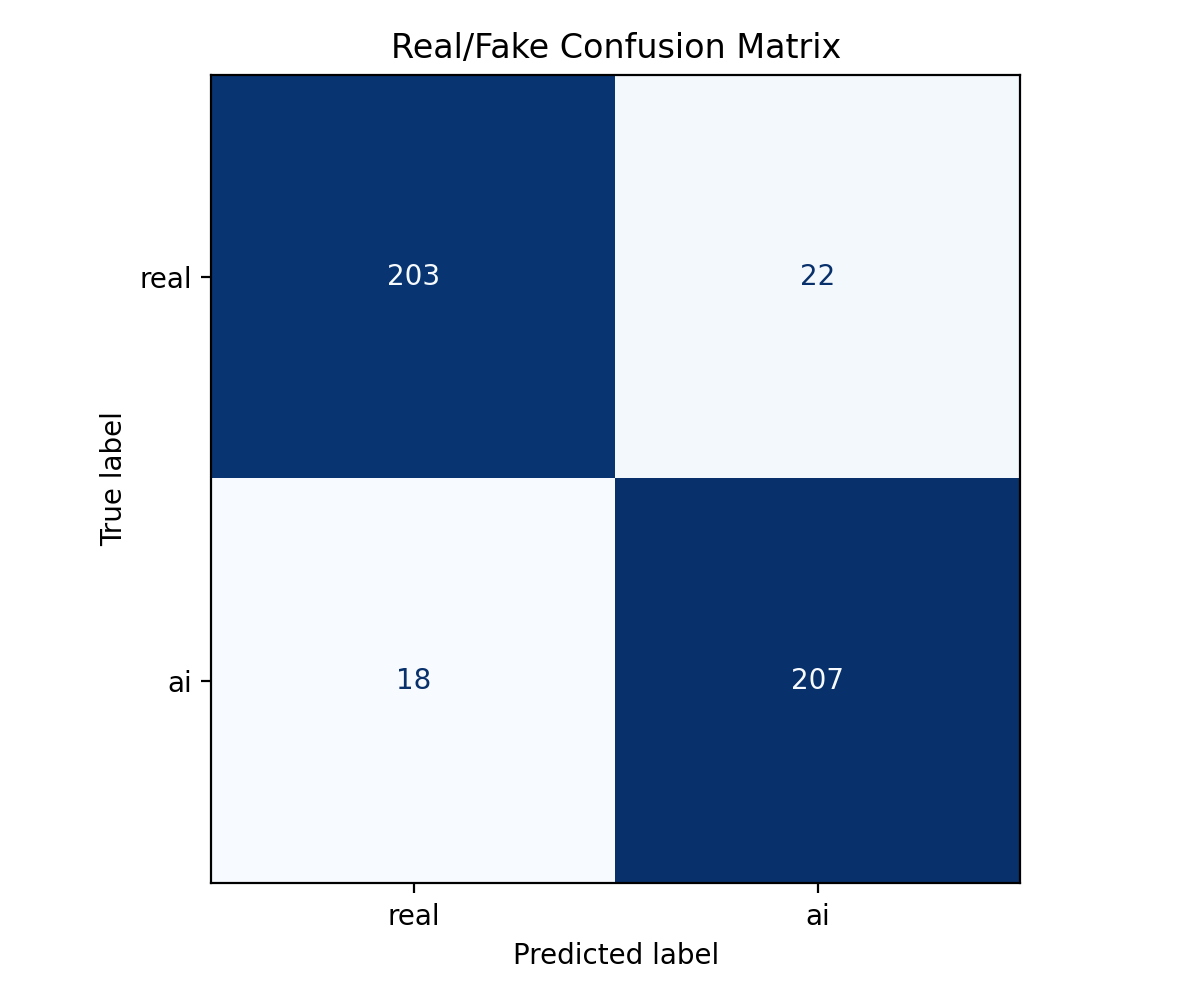

In [ ]:
show_evaluation_outputs("results/rgb_fake")

## Single-task Transformation baseline

This baseline trains the RGB model only on the transformation classification task.

The model predicts whether an image is original, internet-transmitted, or re-digitized.  
This experiment helps us measure how recognizable post-processing traces are when the model is not simultaneously optimized for real/fake detection.

In [ ]:
# Train the transformation single-task baseline.
!python src/train_RGB.py \
  --task transform \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --checkpoint_name best_rgb_transform.pt

Selected task: transform
Using device: cuda

Epoch 1/10
Training: 100% 66/66 [00:40<00:00,  1.63it/s]
Validation: 100% 15/15 [00:10<00:00,  1.41it/s]
Train: {'loss': 1.0418814780598595, 'transform_acc': 0.44904761904761903}
Val:   {'loss': 0.7720059157742394, 'transform_acc': 0.6333333333333333}
Val score: 0.6333
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_transform.pt

Epoch 2/10
Training: 100% 66/66 [00:40<00:00,  1.61it/s]
Validation: 100% 15/15 [00:10<00:00,  1.47it/s]
Train: {'loss': 0.6380939418928964, 'transform_acc': 0.680952380952381}
Val:   {'loss': 0.734990799691942, 'transform_acc': 0.6577777777777778}
Val score: 0.6578
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_transform.pt

Epoch 3/10
Training: 100% 66/66 [00:42<00:00,  1.56it/s]
Validation: 100% 15/15 [00:10<00:00,  1.37it/s]
Train: {'loss': 0.5050634300141107, 'transform_acc': 0.7576190476190476}
Val:   {'loss': 0.5713730332586501, 'transform_acc': 0.7444444444444445}

We evaluate the transformation-only model on the test split and report transformation accuracy, macro F1-score, and the transformation confusion matrix.

In [ ]:
# Evaluate the transformation single-task baseline.
!python src/evaluate_RGB.py \
  --task transform \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_rgb_transform.pt \
  --output_dir results/rgb_transform \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Selected task: transform
Using device: cuda

Evaluation results
Transform accuracy:   0.8133
Transform F1 macro:   0.8118

Saved results in:
results/rgb_transform


Evaluation metrics


,Metric,Group,Value
0,transform_accuracy,-,0.8133
1,transform_f1_macro,-,0.8118



Transformation confusion matrix


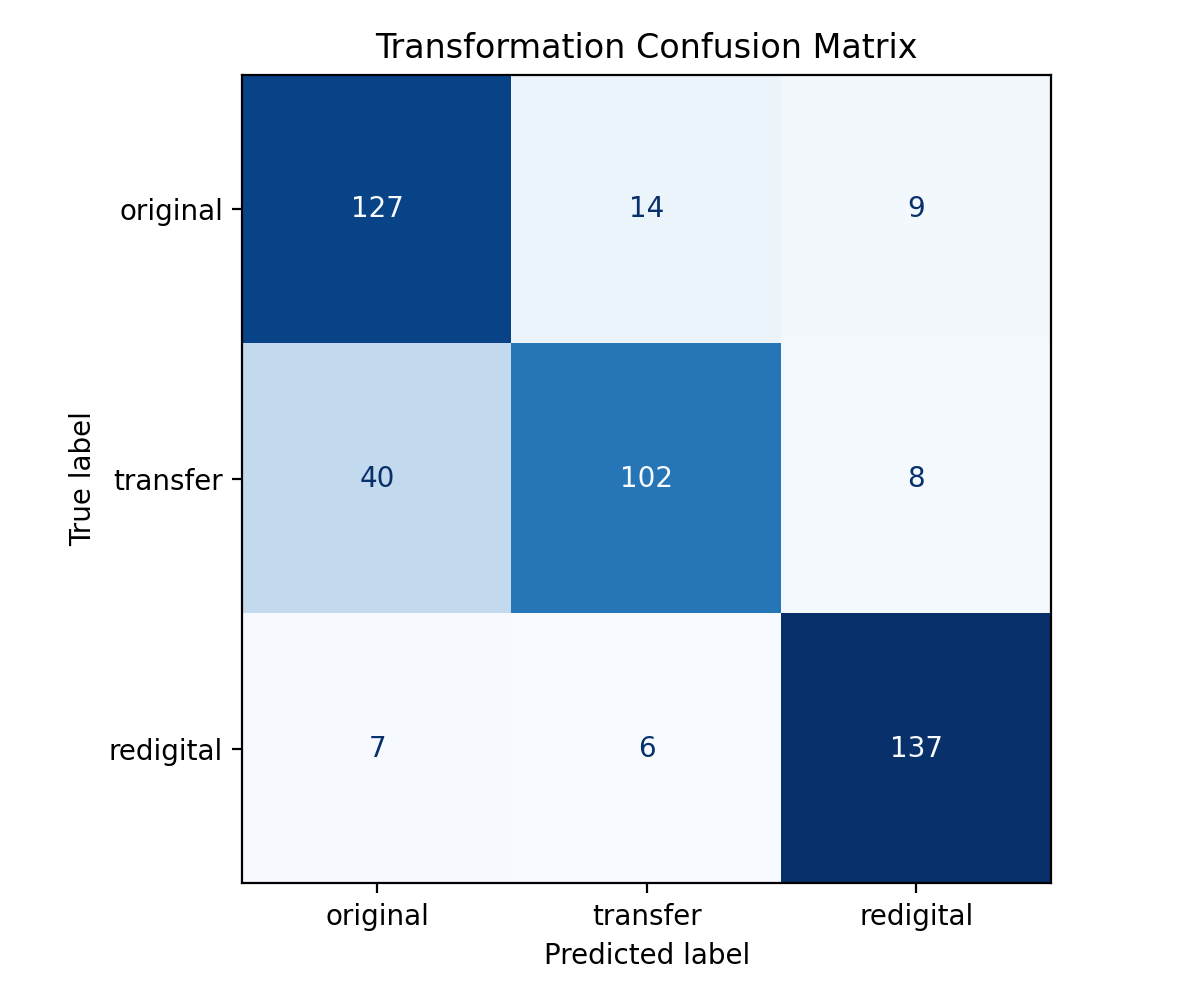

In [ ]:
show_evaluation_outputs("results/rgb_transform")

## RGB Multi-task baseline - manual weights 1.0 / 1.0

This is the standard multi-task baseline.

The model uses a shared RGB backbone and two independent classification heads:

- one head predicts the real/fake label;
- one head predicts the transformation label.

The total loss is computed as:

**L = 1.0 × L_fake + 1.0 × L_transform**

This setting gives equal importance to both tasks.

In [ ]:
# Train the joint RGB multi-task baseline with weights 1 1.
!python src/train_RGB.py \
  --task multitask \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lambda_fake 1.0 \
  --lambda_transform 1.0 \
  --checkpoint_name best_rgb_multitask_1_1.pt

Selected task: multitask
Using device: cuda

Epoch 1/10
Training: 100% 66/66 [00:40<00:00,  1.65it/s]
Validation: 100% 15/15 [00:10<00:00,  1.41it/s]
Train: {'loss': 1.3676882139841715, 'fake_acc': 0.87, 'transform_acc': 0.42523809523809525}
Val:   {'loss': 1.1713831538624233, 'fake_acc': 0.8977777777777778, 'transform_acc': 0.5577777777777778}
Val score: 0.7278
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_multitask_1_1.pt

Epoch 2/10
Training: 100% 66/66 [00:39<00:00,  1.67it/s]
Validation: 100% 15/15 [00:10<00:00,  1.42it/s]
Train: {'loss': 0.7500125441097077, 'fake_acc': 0.9747619047619047, 'transform_acc': 0.6723809523809524}
Val:   {'loss': 0.9110516871346368, 'fake_acc': 0.9244444444444444, 'transform_acc': 0.6866666666666666}
Val score: 0.8056
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_multitask_1_1.pt

Epoch 3/10
Training: 100% 66/66 [00:39<00:00,  1.66it/s]
Validation: 100% 15/15 [00:09<00:00,  1.58it/s]
Train: {'loss': 0.551

In [ ]:
# Evaluate the joint RGB multi-task baseline with weights 1 1.
!python src/evaluate_RGB.py \
  --task multitask \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_rgb_multitask_1_1.pt \
  --output_dir results/rgb_multitask_1_1 \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Selected task: multitask
Using device: cuda

Evaluation results
Fake accuracy:        0.9222
Fake F1 macro:        0.9221

Fake accuracy by transformation:
  original: 0.9333
  transfer: 0.9267
  redigital: 0.9067
Transform accuracy:   0.7822
Transform F1 macro:   0.7816

Saved results in:
results/rgb_multitask_1_1


Evaluation metrics


,Metric,Group,Value
0,fake_accuracy,-,0.9222
1,fake_f1_macro,-,0.9221
2,fake_accuracy_by_transform,original,0.9333
3,fake_accuracy_by_transform,transfer,0.9267
4,fake_accuracy_by_transform,redigital,0.9067
5,transform_accuracy,-,0.7822
6,transform_f1_macro,-,0.7816



Real/Fake confusion matrix


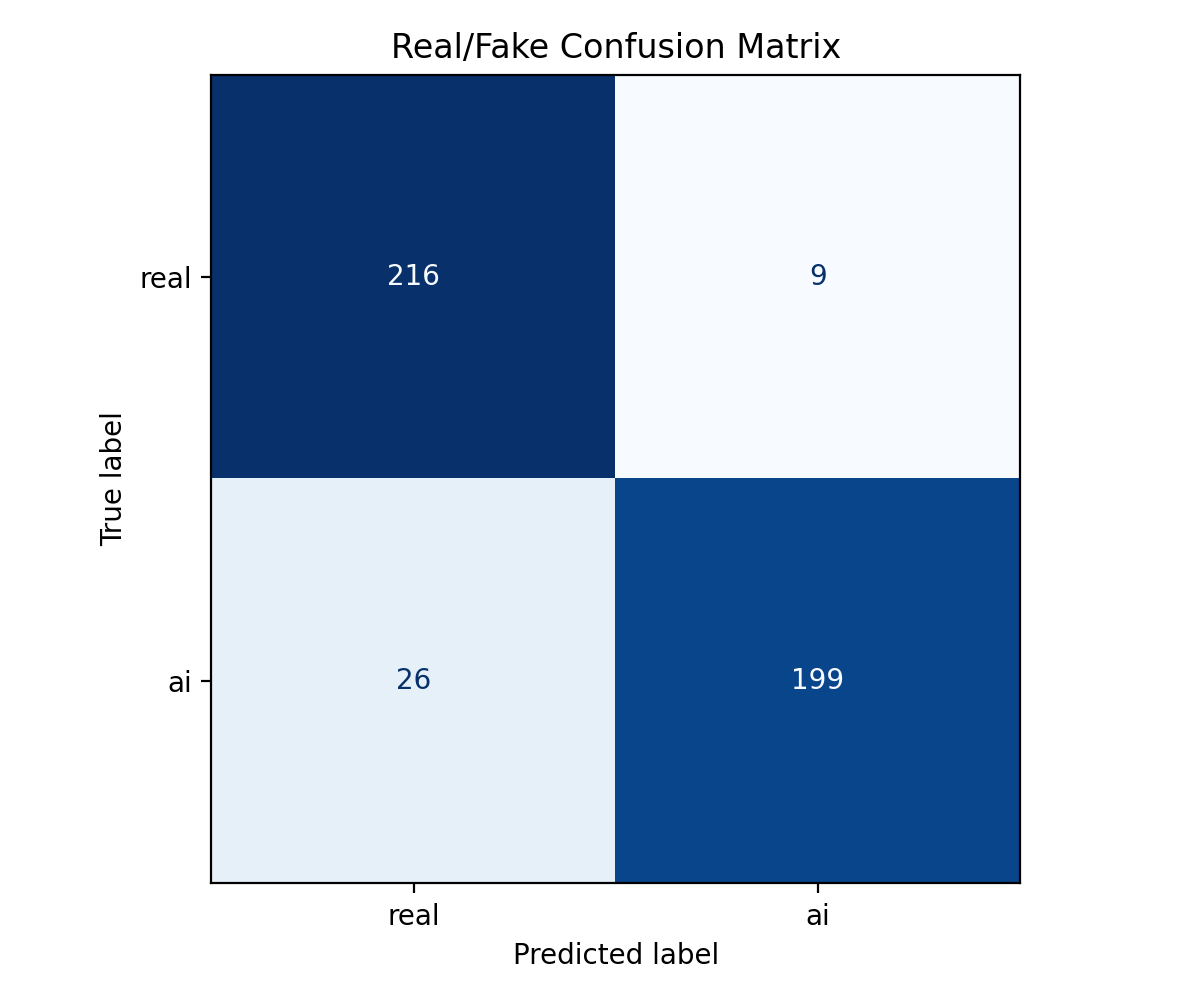


Transformation confusion matrix


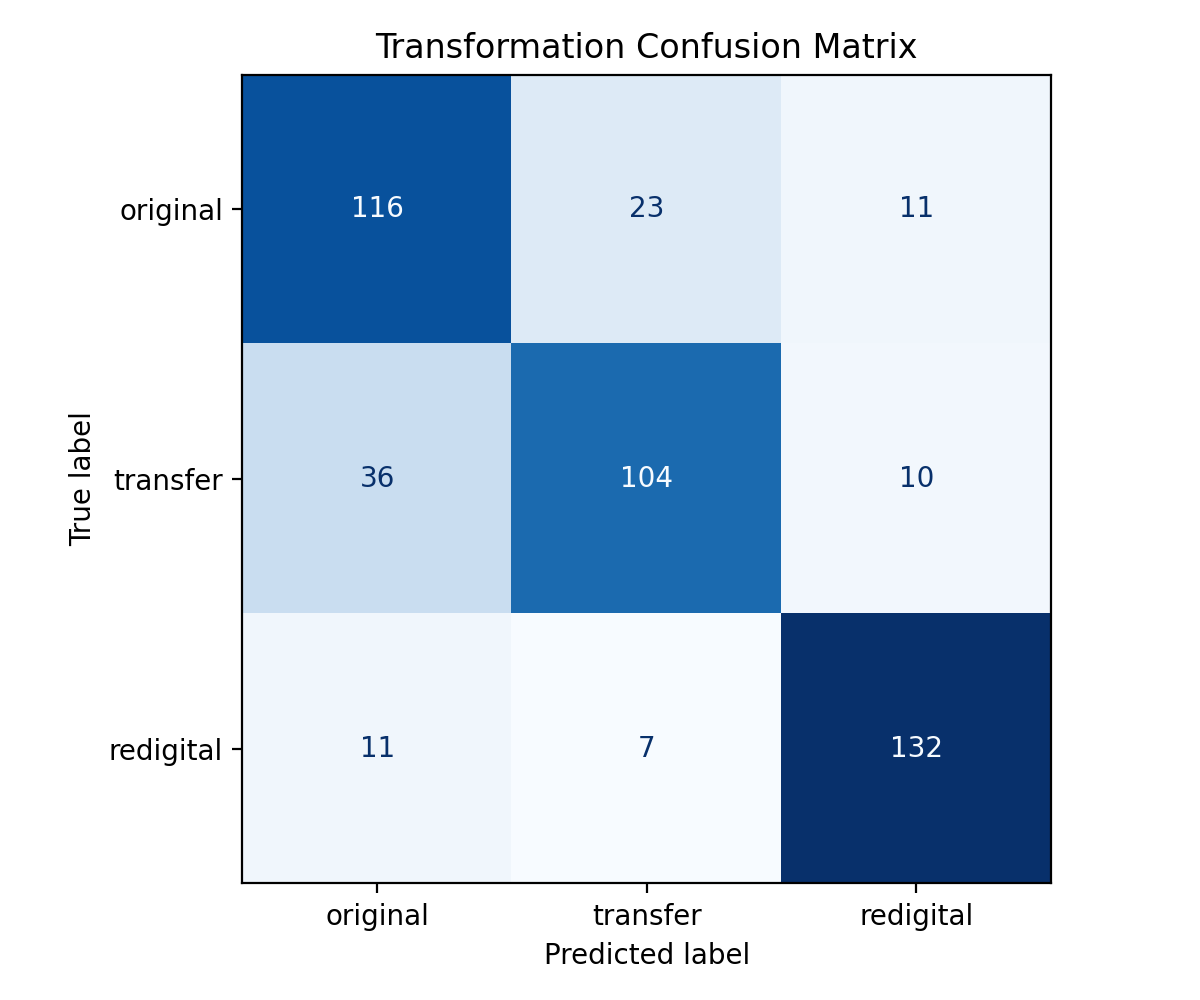

In [ ]:
show_evaluation_outputs("results/rgb_multitask_1_1")

## RGB Multi-task baseline - manual weights 1.0 / 2.0

In this experiment, the transformation loss receives a higher weight than the real/fake loss:

**L = 1.0 × L_fake + 2.0 × L_transform**

The goal is to test whether forcing the model to focus more on transformation recognition also improves real/fake detection.

In [ ]:
# Train the joint RGB multi-task baseline with weights 1 2.
!python src/train_RGB.py \
  --task multitask \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lambda_fake 1.0 \
  --lambda_transform 2.0 \
  --checkpoint_name best_rgb_multitask_1_2.pt

Selected task: multitask
Using device: cuda

Epoch 1/10
Training: 100% 66/66 [00:39<00:00,  1.66it/s]
Validation: 100% 15/15 [00:09<00:00,  1.51it/s]
Train: {'loss': 2.428954931894938, 'fake_acc': 0.8361904761904762, 'transform_acc': 0.4504761904761905}
Val:   {'loss': 1.8462811109754775, 'fake_acc': 0.9111111111111111, 'transform_acc': 0.5955555555555555}
Val score: 0.7533
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_multitask_1_2.pt

Epoch 2/10
Training: 100% 66/66 [00:39<00:00,  1.67it/s]
Validation: 100% 15/15 [00:10<00:00,  1.40it/s]
Train: {'loss': 1.4776687469936554, 'fake_acc': 0.9485714285714286, 'transform_acc': 0.6614285714285715}
Val:   {'loss': 1.5610975530412463, 'fake_acc': 0.8955555555555555, 'transform_acc': 0.7311111111111112}
Val score: 0.8133
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_multitask_1_2.pt

Epoch 3/10
Training: 100% 66/66 [00:39<00:00,  1.66it/s]
Validation: 100% 15/15 [00:10<00:00,  1.42it/s]
Train: {'

In [ ]:
# Evaluate the joint RGB multi-task baseline with weights 1 2.
!python src/evaluate_RGB.py \
  --task multitask \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_rgb_multitask_1_2.pt \
  --output_dir results/rgb_multitask_1_2 \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Selected task: multitask
Using device: cuda

Evaluation results
Fake accuracy:        0.9267
Fake F1 macro:        0.9266

Fake accuracy by transformation:
  original: 0.9333
  transfer: 0.9267
  redigital: 0.9200
Transform accuracy:   0.8222
Transform F1 macro:   0.8227

Saved results in:
results/rgb_multitask_1_2


Evaluation metrics


,Metric,Group,Value
0,fake_accuracy,-,0.9267
1,fake_f1_macro,-,0.9266
2,fake_accuracy_by_transform,original,0.9333
3,fake_accuracy_by_transform,transfer,0.9267
4,fake_accuracy_by_transform,redigital,0.9200
5,transform_accuracy,-,0.8222
6,transform_f1_macro,-,0.8227



Real/Fake confusion matrix


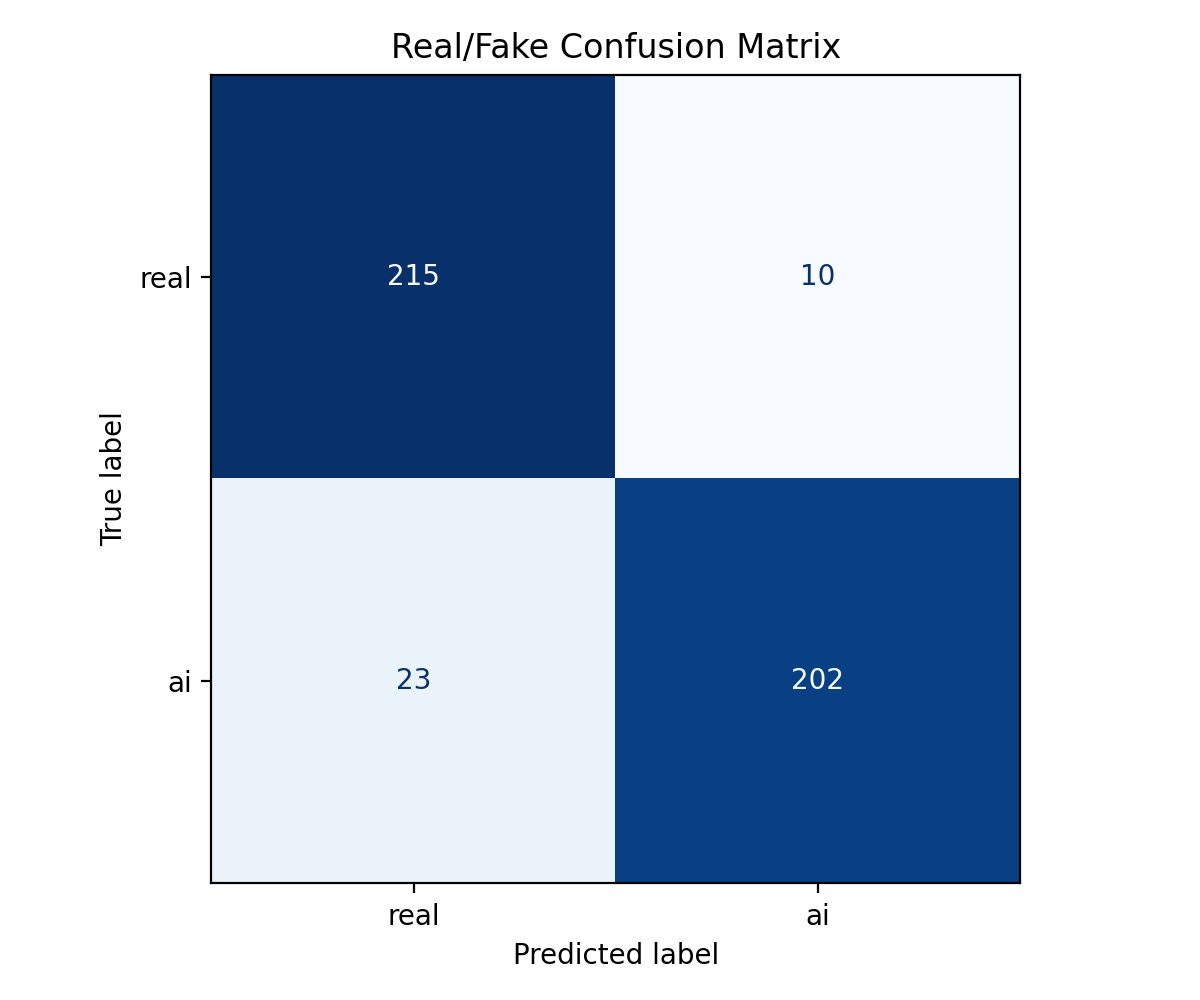


Transformation confusion matrix


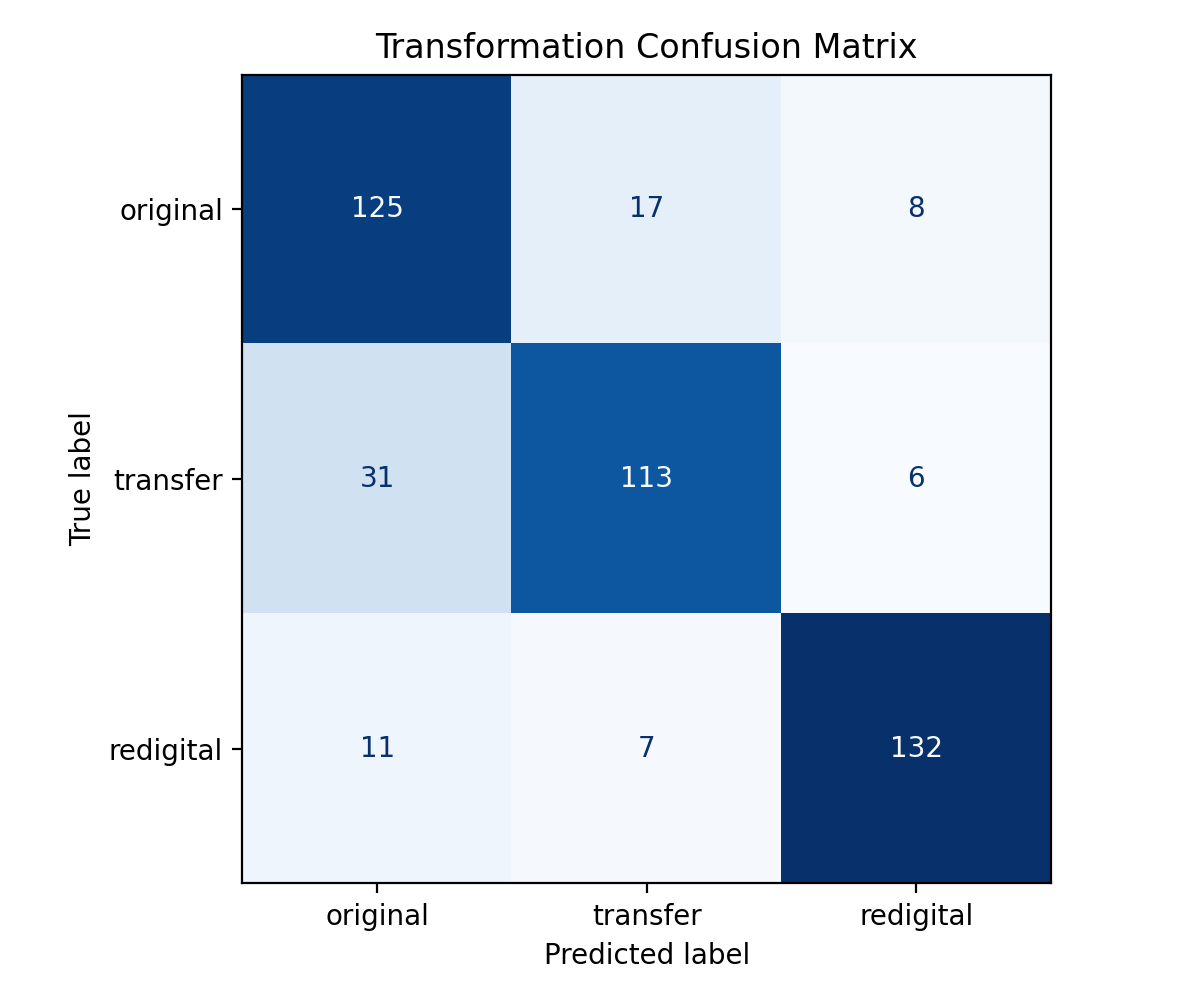

In [ ]:
show_evaluation_outputs("results/rgb_multitask_1_2")

## RGB Multi-task baseline - manual weights 2.0 / 1.0

In this experiment, the real/fake loss receives a higher weight than the transformation loss:

**L = 2.0 × L_fake + 1.0 × L_transform**

This setting prioritizes the main forensic task while still keeping transformation classification as an auxiliary task.

In [ ]:
# Train the joint RGB multi-task baseline with weights 2 1.
!python src/train_RGB.py \
  --task multitask \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lambda_fake 2.0 \
  --lambda_transform 1.0 \
  --checkpoint_name best_rgb_multitask_2_1.pt

Selected task: multitask
Using device: cuda

Epoch 1/10
Training: 100% 66/66 [00:39<00:00,  1.65it/s]
Validation: 100% 15/15 [00:09<00:00,  1.54it/s]
Train: {'loss': 1.5750467804500035, 'fake_acc': 0.8923809523809524, 'transform_acc': 0.44047619047619047}
Val:   {'loss': 1.3615152184168497, 'fake_acc': 0.9022222222222223, 'transform_acc': 0.5822222222222222}
Val score: 0.7422
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_multitask_2_1.pt

Epoch 2/10
Training: 100% 66/66 [00:39<00:00,  1.66it/s]
Validation: 100% 15/15 [00:10<00:00,  1.39it/s]
Train: {'loss': 0.8271855131785075, 'fake_acc': 0.9852380952380952, 'transform_acc': 0.6261904761904762}
Val:   {'loss': 1.166947561899821, 'fake_acc': 0.9444444444444444, 'transform_acc': 0.6577777777777778}
Val score: 0.8011
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_multitask_2_1.pt

Epoch 3/10
Training: 100% 66/66 [00:39<00:00,  1.66it/s]
Validation: 100% 15/15 [00:10<00:00,  1.40it/s]
Train: {

In [ ]:
# Evaluate the joint RGB multi-task baseline with weights 2 1.
!python src/evaluate_RGB.py \
  --task multitask \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_rgb_multitask_2_1.pt \
  --output_dir results/rgb_multitask_2_1 \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Selected task: multitask
Using device: cuda

Evaluation results
Fake accuracy:        0.9244
Fake F1 macro:        0.9243

Fake accuracy by transformation:
  original: 0.9267
  transfer: 0.9200
  redigital: 0.9267
Transform accuracy:   0.8022
Transform F1 macro:   0.8043

Saved results in:
results/rgb_multitask_2_1


Evaluation metrics


,Metric,Group,Value
0,fake_accuracy,-,0.9244
1,fake_f1_macro,-,0.9243
2,fake_accuracy_by_transform,original,0.9267
3,fake_accuracy_by_transform,transfer,0.9200
4,fake_accuracy_by_transform,redigital,0.9267
5,transform_accuracy,-,0.8022
6,transform_f1_macro,-,0.8043



Real/Fake confusion matrix


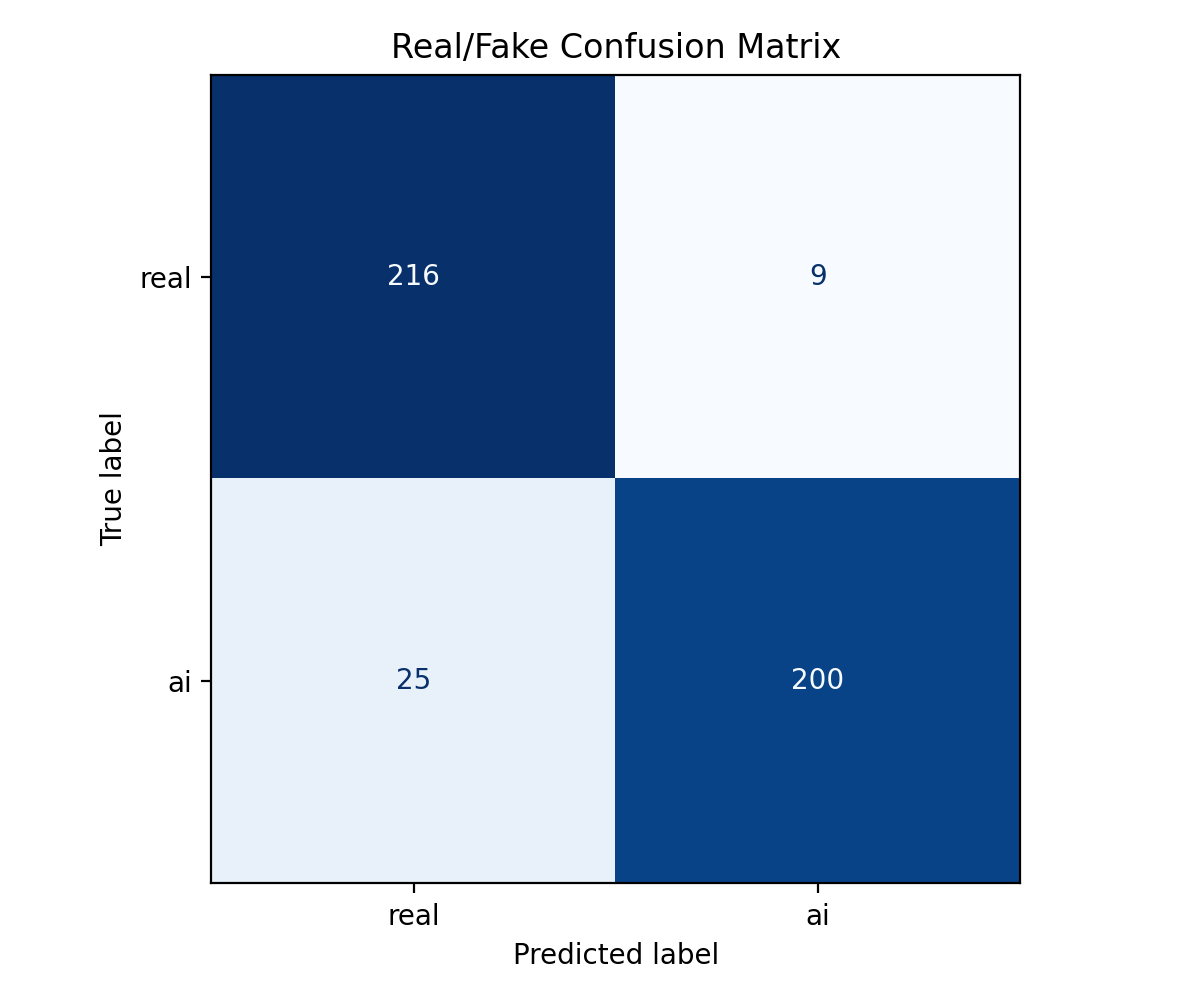


Transformation confusion matrix


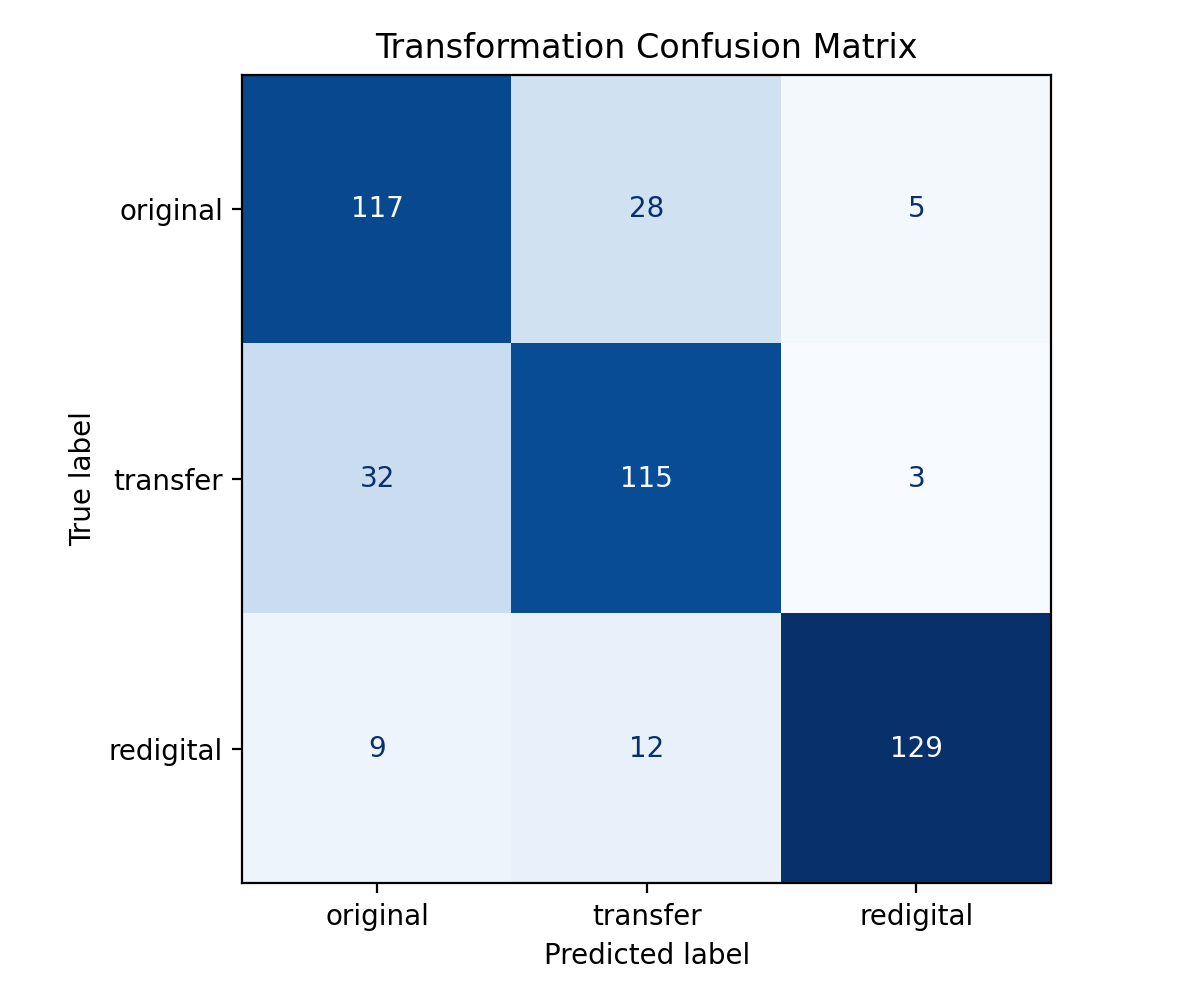

In [ ]:
show_evaluation_outputs("results/rgb_multitask_2_1")

## RGB Multi-task baseline - Learned Uncertainty Weighting

This experiment replaces manually selected loss weights with learned uncertainty-based weights.

Instead of fixing the relative importance of the two tasks before training, the model learns how much each task should contribute to the total loss.

This is useful because the two tasks may have different difficulty levels. If one task is noisier or harder, the learned weighting mechanism can reduce its dominance and make the multi-task optimization more balanced.

In [ ]:
# Train the joint RGB multi-task baseline with Learned Uncertainty Weighting
!python src/train_RGB.py \
  --task multitask \
  --loss_weighting learned \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --checkpoint_name best_rgb_multitask_learned_weights.pt

Selected task: multitask
Using device: cuda

Epoch 1/10
Training: 100% 66/66 [00:40<00:00,  1.64it/s]
Validation: 100% 15/15 [00:10<00:00,  1.41it/s]
Train: {'loss': 1.3445749791463215, 'fake_acc': 0.8714285714285714, 'transform_acc': 0.4419047619047619, 'weight_fake': 1.0034671606439534, 'weight_transform': 0.9978553526329271}
Val:   {'loss': 1.1589186579651303, 'fake_acc': 0.92, 'transform_acc': 0.5844444444444444, 'weight_fake': 1.007197380065918, 'weight_transform': 0.997456967830658}
Learned loss weights (train): fake=1.0035, transform=0.9979
Learned loss weights (val):   fake=1.0072, transform=0.9975
Val score: 0.7522
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_rgb_multitask_learned_weights.pt

Epoch 2/10
Training: 100% 66/66 [00:40<00:00,  1.65it/s]
Validation: 100% 15/15 [00:10<00:00,  1.42it/s]
Train: {'loss': 0.759788255464463, 'fake_acc': 0.9733333333333334, 'transform_acc': 0.6557142857142857, 'weight_fake': 1.010973704583717, 'weight_transform': 1.001

In [ ]:
# Evaluate the joint RGB multi-task baseline with Learned Uncertainty Weighting
!python src/evaluate_RGB.py \
  --task multitask \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_rgb_multitask_learned_weights.pt \
  --output_dir results/rgb_multitask_learned_weights \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Selected task: multitask
Using device: cuda

Evaluation results
Fake accuracy:        0.9222
Fake F1 macro:        0.9222

Fake accuracy by transformation:
  original: 0.9333
  transfer: 0.9267
  redigital: 0.9067
Transform accuracy:   0.7867
Transform F1 macro:   0.7834

Saved results in:
results/rgb_multitask_learned_weights


Evaluation metrics


,Metric,Group,Value
0,fake_accuracy,-,0.9222
1,fake_f1_macro,-,0.9222
2,fake_accuracy_by_transform,original,0.9333
3,fake_accuracy_by_transform,transfer,0.9267
4,fake_accuracy_by_transform,redigital,0.9067
5,transform_accuracy,-,0.7867
6,transform_f1_macro,-,0.7834



Real/Fake confusion matrix


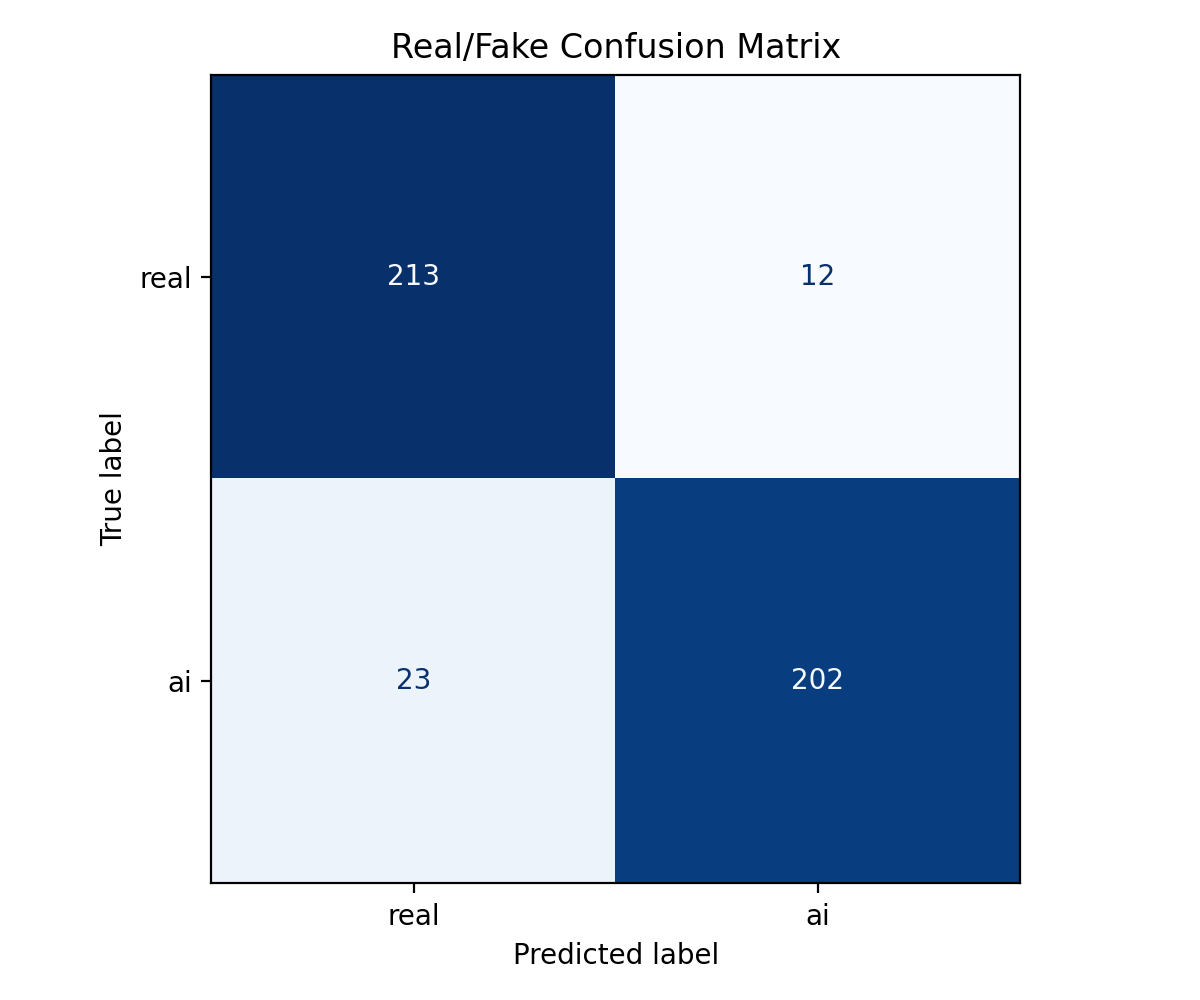


Transformation confusion matrix


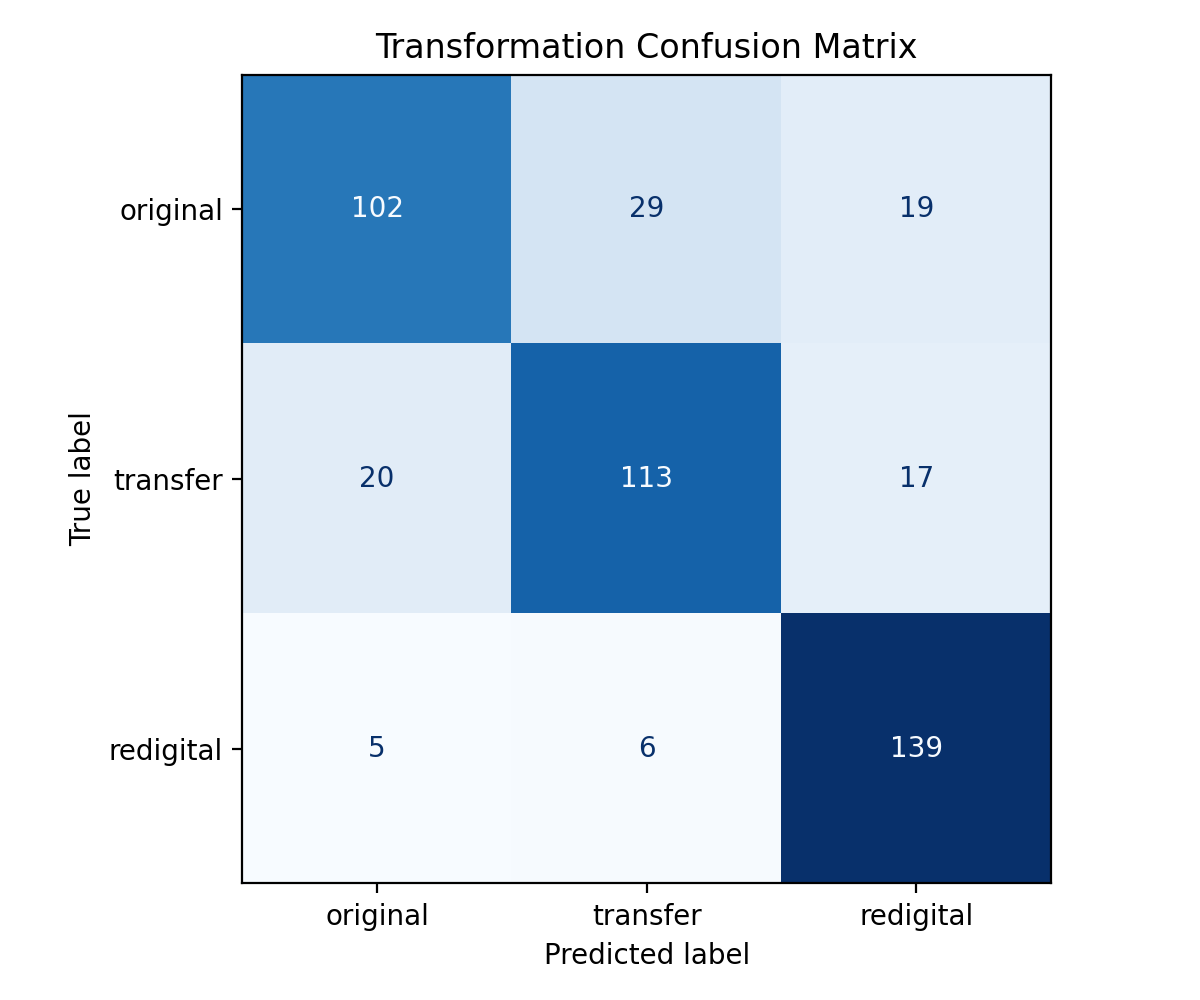

In [ ]:
show_evaluation_outputs("results/rgb_multitask_learned_weights")

## Results Comparison and Ablation Study

This section compares the RGB baselines and the RGB multi-task models.

The objective is to understand whether the transformation task helps the real/fake detector learn more robust features, or whether the two objectives interfere with each other during training.

We also compare different loss-weighting strategies, since changing the relative importance of the two losses can affect the balance between real/fake accuracy and transformation accuracy.

Finally, we report real/fake accuracy by transformation type to check whether the model remains reliable on original, transmitted, and re-digitized images.

In [ ]:
results = {
    "RGB fake-only": "results/rgb_fake/metrics.json",
    "RGB transform-only": "results/rgb_transform/metrics.json",
    "RGB multitask 1-1": "results/rgb_multitask_1_1/metrics.json",
    "RGB multitask 1-2": "results/rgb_multitask_1_2/metrics.json",
    "RGB multitask 2-1": "results/rgb_multitask_2_1/metrics.json",
    "RGB multitask learned": "results/rgb_multitask_learned_weights/metrics.json",
}

rows = []

for model_name, metrics_path in results.items():
    metrics_path = Path(metrics_path)

    if not metrics_path.exists():
        print(f"Missing file: {metrics_path}")
        continue

    with open(metrics_path, "r") as f:
        metrics = json.load(f)

    rows.append({
        "model": model_name,
        "fake_accuracy": metrics.get("fake_accuracy"),
        "fake_f1_macro": metrics.get("fake_f1_macro"),
        "transform_accuracy": metrics.get("transform_accuracy"),
        "transform_f1_macro": metrics.get("transform_f1_macro"),
        "fake_acc_original": metrics.get("fake_accuracy_by_transform", {}).get("original"),
        "fake_acc_transfer": metrics.get("fake_accuracy_by_transform", {}).get("transfer"),
        "fake_acc_redigital": metrics.get("fake_accuracy_by_transform", {}).get("redigital"),
    })

comparison_df = pd.DataFrame(rows)
comparison_df.sort_values(
    by=["fake_accuracy", "transform_accuracy"],
    ascending=False
)

,model,fake_accuracy,fake_f1_macro,transform_accuracy,transform_f1_macro,fake_acc_original,fake_acc_transfer,fake_acc_redigital
3,RGB multitask 1-2,0.926667,0.926605,0.822222,0.822664,0.933333,0.926667,0.920000
4,RGB multitask 2-1,0.924444,0.924349,0.802222,0.804264,0.926667,0.920000,0.926667
5,RGB multitask learned,0.922222,0.922176,0.786667,0.783412,0.933333,0.926667,0.906667
2,RGB multitask 1-1,0.922222,0.922111,0.782222,0.781632,0.933333,0.926667,0.906667
0,RGB fake-only,0.911111,0.911104,NaN,NaN,0.920000,0.913333,0.900000
1,RGB transform-only,NaN,NaN,0.813333,0.811755,NaN,NaN,NaN


### Global accuracy comparison

The following plot compares the main accuracy scores across RGB experiments.

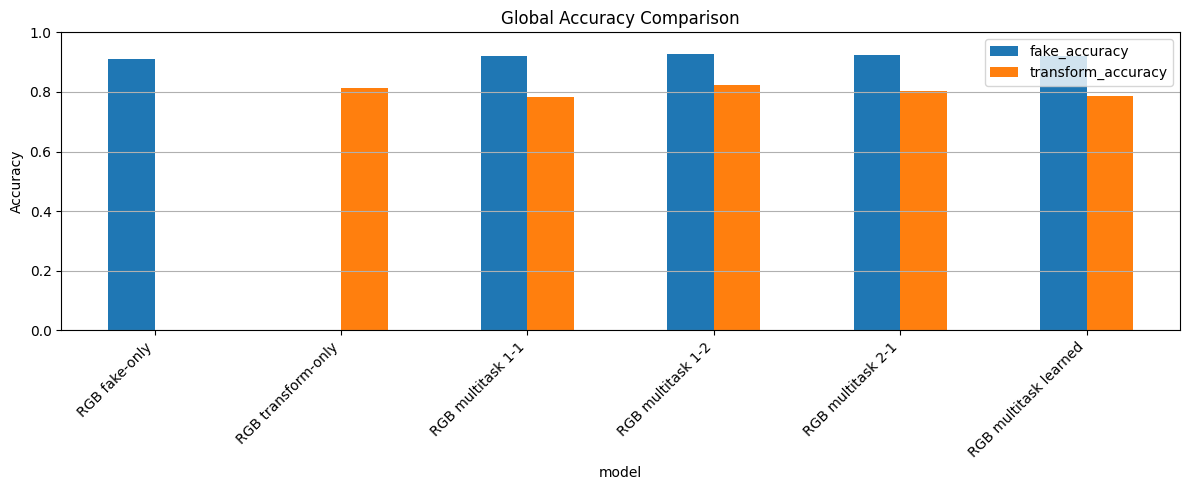

In [ ]:
# Global Accuracy Comparison

plot_df = comparison_df.set_index("model")

plot_df[["fake_accuracy", "transform_accuracy"]].plot(
    kind="bar",
    figsize=(12, 5),
)

plt.title("Global Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

### Real/Fake accuracy by transformation type

This analysis breaks down real/fake detection accuracy across transformation categories.

This is important because the main challenge of the project is not only detecting AI-generated images in clean conditions, but also maintaining robustness after real-world post-processing.

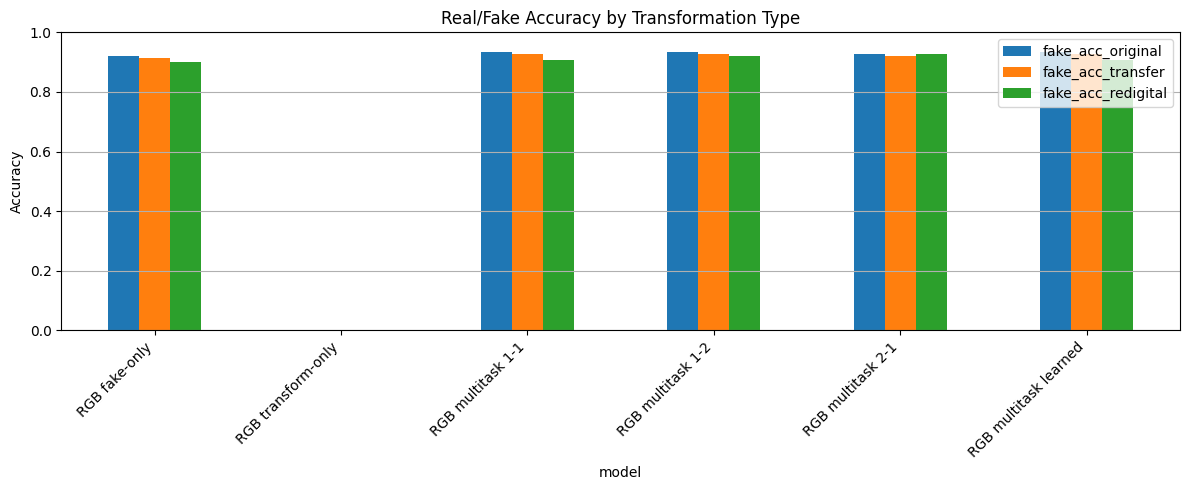

In [ ]:
# Real/Fake Accuracy by Transformation Type
plot_df[[
    "fake_acc_original",
    "fake_acc_transfer",
    "fake_acc_redigital",
]].plot(
    kind="bar",
    figsize=(12, 5),
)

plt.title("Real/Fake Accuracy by Transformation Type")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

#Frequency

GANs genereate periodic artifacts, invisibles in RGB, but that can be detect in frequency domain.
Is used FFT on the amplitude log-spectrum.



##Standard Applycation
lambda_fake=1.0 and lambda_transform=1.0

**Train**

In [ ]:
# Frequency multi-task using weights 1.0 / 1.0
!python src/train_freq.py \
  --train_csv        {TRAIN_CSV} \
  --val_csv          {VAL_CSV} \
  --image_root       {IMAGE_ROOT} \
  --epochs           {EPOCHS} \
  --batch_size       {BATCH_SIZE} \
  --image_size       {IMAGE_SIZE} \
  --num_workers      {NUM_WORKERS} \
  --lambda_fake      1.0 \
  --lambda_transform 1.0 \
  --checkpoint_name  best_freq_multitask_1_1.pt

Using device: cuda

Epoch 1/10
Training freq: 100% 66/66 [00:44<00:00,  1.48it/s]
Validation freq: 100% 15/15 [00:10<00:00,  1.41it/s]
Train: {'loss': 1.4424609290985835, 'fake_acc': 0.8414285714285714, 'transform_acc': 0.4142857142857143}
Val:   {'loss': 1.104069407251146, 'fake_acc': 0.9088888888888889, 'transform_acc': 0.58}
Val score: 0.7444
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_freq_multitask_1_1.pt

Epoch 2/10
Training freq: 100% 66/66 [00:42<00:00,  1.55it/s]
Validation freq: 100% 15/15 [00:10<00:00,  1.45it/s]
Train: {'loss': 0.8737686617033822, 'fake_acc': 0.9604761904761905, 'transform_acc': 0.6071428571428571}
Val:   {'loss': 1.0882111565272012, 'fake_acc': 0.9177777777777778, 'transform_acc': 0.6244444444444445}
Val score: 0.7711
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_freq_multitask_1_1.pt

Epoch 3/10
Training freq: 100% 66/66 [00:43<00:00,  1.52it/s]
Validation freq: 100% 15/15 [00:10<00:00,  1.40it/s]
Train: {'loss': 

**Evaluate**

In [ ]:
!python src/evaluate_freq.py \
  --csv_path    {TEST_CSV} \
  --image_root  {IMAGE_ROOT} \
  --checkpoint  checkpoints/best_freq_multitask_1_1.pt \
  --output_dir  results/freq_multitask_1_1 \
  --batch_size  {BATCH_SIZE} \
  --image_size  {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Using device: cuda

Evaluation results — Frequency model
Fake accuracy:        0.9022
Fake F1 macro:        0.9022
Transform accuracy:   0.8244
Transform F1 macro:   0.8240

Fake accuracy by transformation:
  original: 0.9067
  transfer: 0.9067
  redigital: 0.8933

Saved results in: results/freq_multitask_1_1


**Results**

Evaluation metrics


,Metric,Group,Value
0,fake_accuracy,-,0.9022
1,fake_f1_macro,-,0.9022
2,transform_accuracy,-,0.8244
3,transform_f1_macro,-,0.8240
4,fake_accuracy_by_transform,original,0.9067
5,fake_accuracy_by_transform,transfer,0.9067
6,fake_accuracy_by_transform,redigital,0.8933



Real/Fake confusion matrix


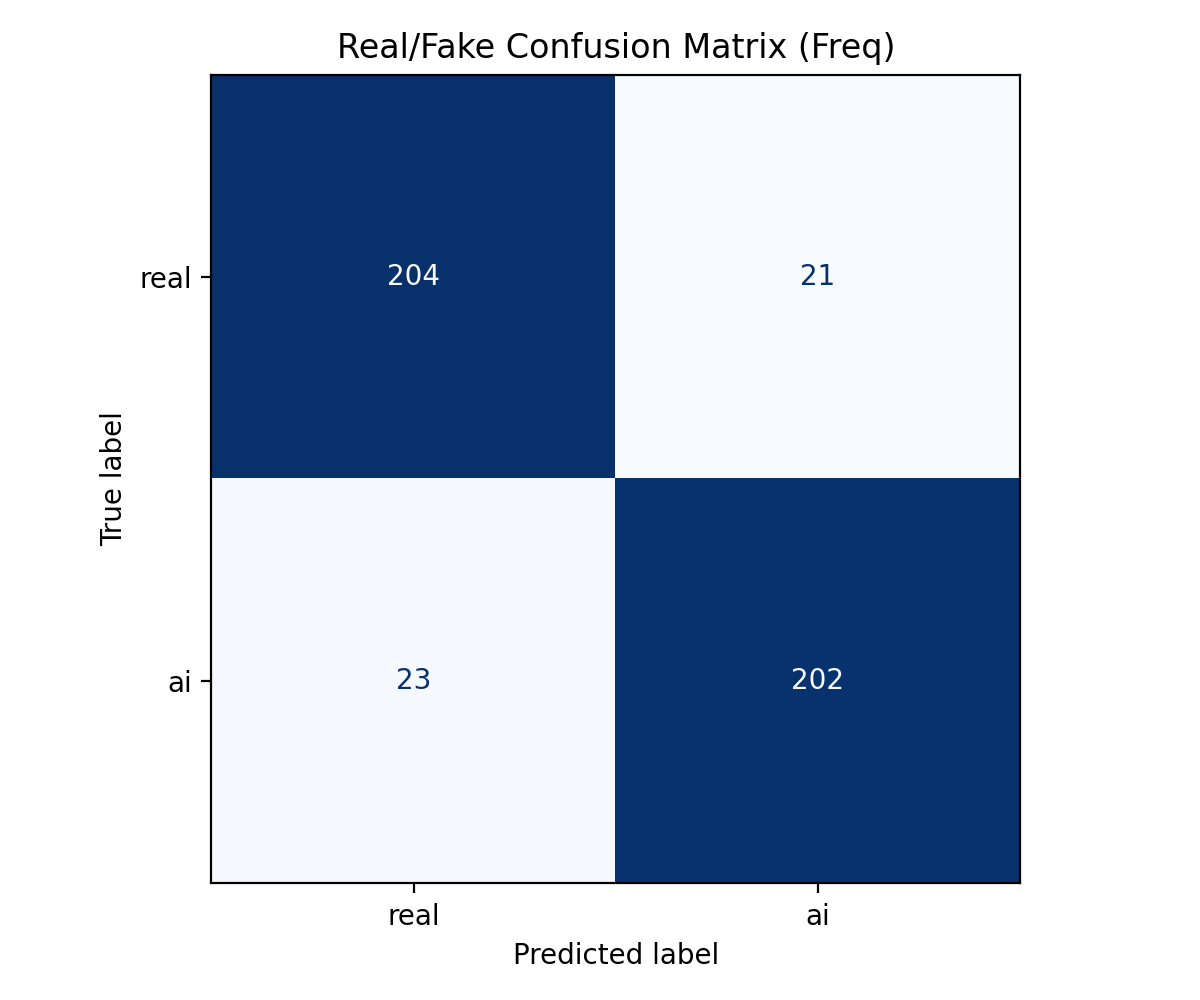


Transformation confusion matrix


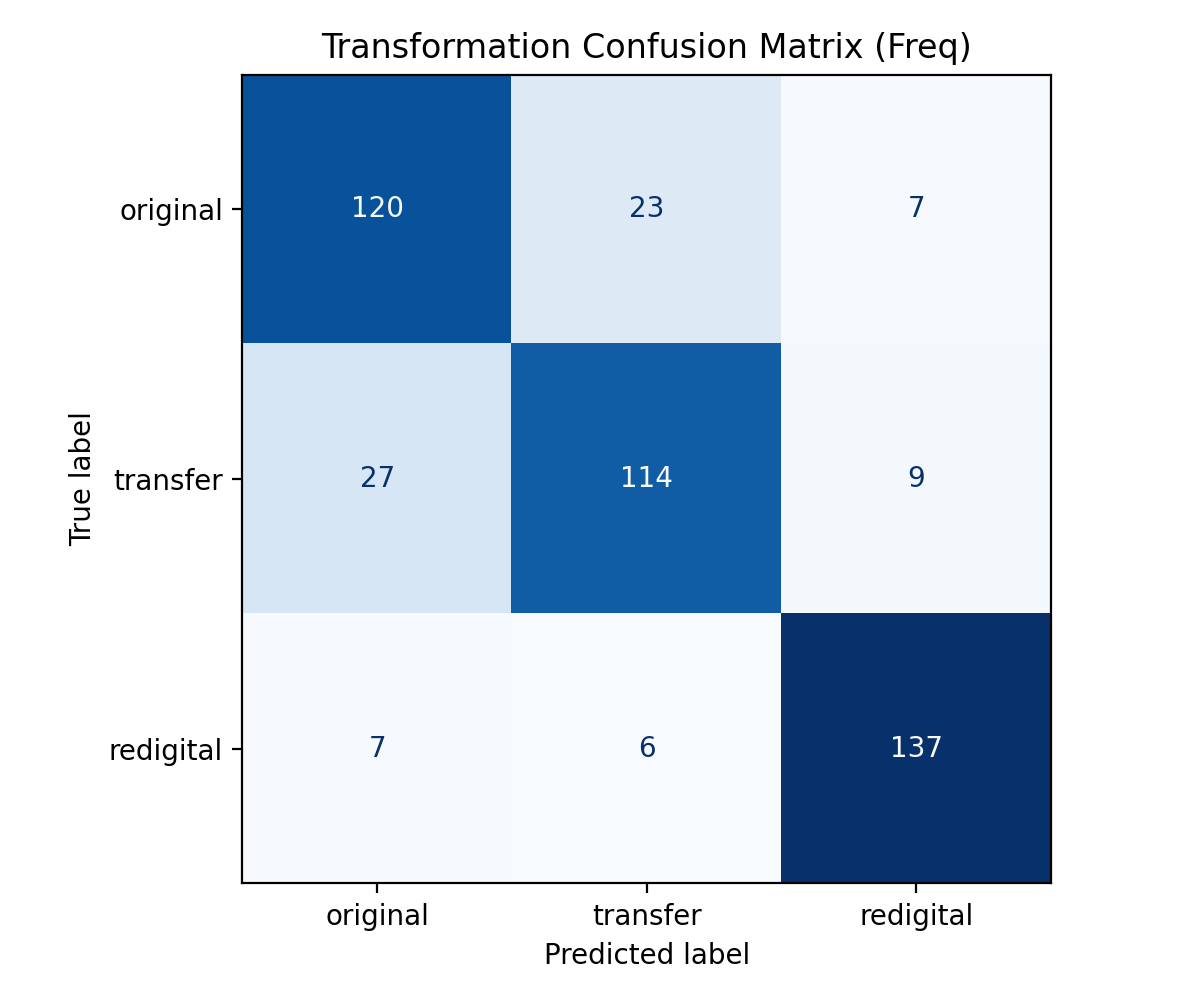

In [ ]:
show_evaluation_outputs("results/freq_multitask_1_1")

**Comparison**

In [ ]:
!python src/compare.py

python3: can't open file '/content/REPO/src/compare.py': [Errno 2] No such file or directory


##Improvement
**Different training Cosine scheduler with warm-up and Learned uncertainty weighting**

In [ ]:
!python src/FrequencyAugumented.py \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --num_workers {NUM_WORKERS} \
  --scheduler cosine \
  --warmup_epochs 2 \
  --loss_weighting learned \
  --checkpoint_name best_freq.pt

Using device: cuda
Scheduler:    cosine
Loss weights: learned
Learned uncertainty weighting enabled.
  Initial log_var_fake:      0.0000
  Initial log_var_transform: 0.0000

Epoch 1/10
Training freq: 100% 66/66 [00:42<00:00,  1.54it/s]
Validation freq: 100% 15/15 [00:11<00:00,  1.34it/s]
Train: {'loss': 1.755135559581575, 'fake_acc': 0.6514285714285715, 'transform_acc': 0.3580952380952381, 'w_fake': 1.0003307335304492, 'w_transform': 0.9996821988712657}
Val:   {'loss': 1.7038827255037097, 'fake_acc': 0.76, 'transform_acc': 0.3933333333333333}
Val score:     0.5767
Learning rate: 0.000011
Learned w_fake: 1.0007  |  w_transform: 0.9994
Saved best checkpoint → checkpoints/best_freq.pt

Epoch 2/10
Training freq: 100% 66/66 [00:42<00:00,  1.55it/s]
Validation freq: 100% 15/15 [00:11<00:00,  1.35it/s]
Train: {'loss': 1.6439385661624726, 'fake_acc': 0.8152380952380952, 'transform_acc': 0.3976190476190476, 'w_fake': 1.001073830055468, 'w_transform': 0.999051753318671}
Val:   {'loss': 1.5832189

**Evaluation**

In [ ]:
!python src/evaluate_freq_agu.py \
  --csv_path   {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_freq.pt\
  --output_dir results/freq_aug \
  --batch_size 32 --num_workers {NUM_WORKERS}

Using device: cuda
Evaluating freq: 100% 15/15 [00:08<00:00,  1.77it/s]

Evaluation results — Frequency model (RGB + FFT)
Fake accuracy:        0.9267
Fake F1 macro:        0.9265

Fake accuracy by transformation:
  original: 0.9333
  transfer: 0.9400
  redigital: 0.9067

Transform accuracy:   0.7200
Transform F1 macro:   0.7144

Saved results in: results/freq_aug


**Results**

Evaluation metrics


,Metric,Group,Value
0,fake_accuracy,-,0.9267
1,fake_f1_macro,-,0.9265
2,fake_accuracy_by_transform,original,0.9333
3,fake_accuracy_by_transform,transfer,0.9400
4,fake_accuracy_by_transform,redigital,0.9067
5,transform_accuracy,-,0.7200
6,transform_f1_macro,-,0.7144
7,fake_classification_report,real,"{'precision': 0.8934426229508197, 'recall': 0...."
8,fake_classification_report,ai,"{'precision': 0.9660194174757282, 'recall': 0...."
9,fake_classification_report,accuracy,0.9267



Real/Fake confusion matrix


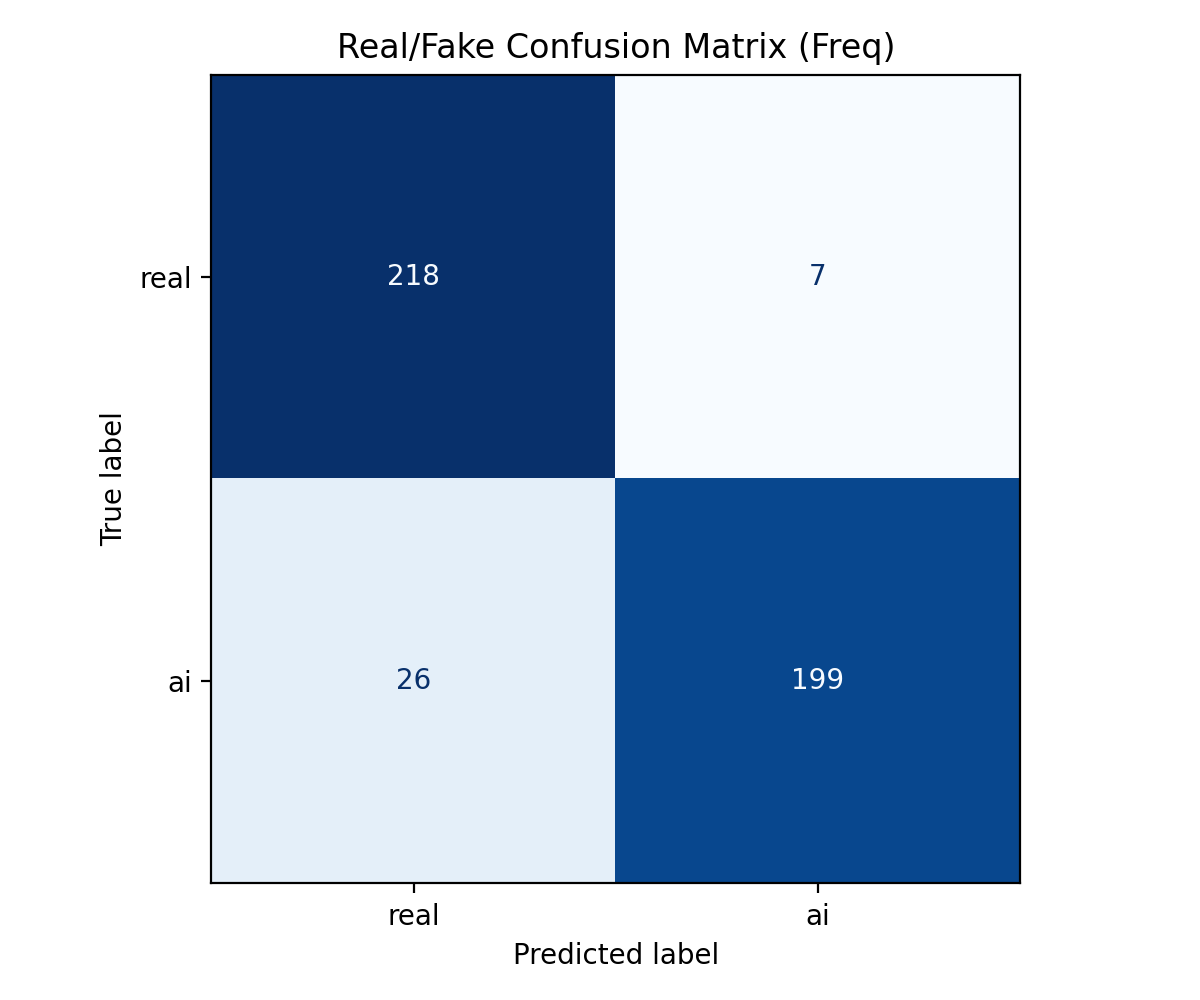


Transformation confusion matrix


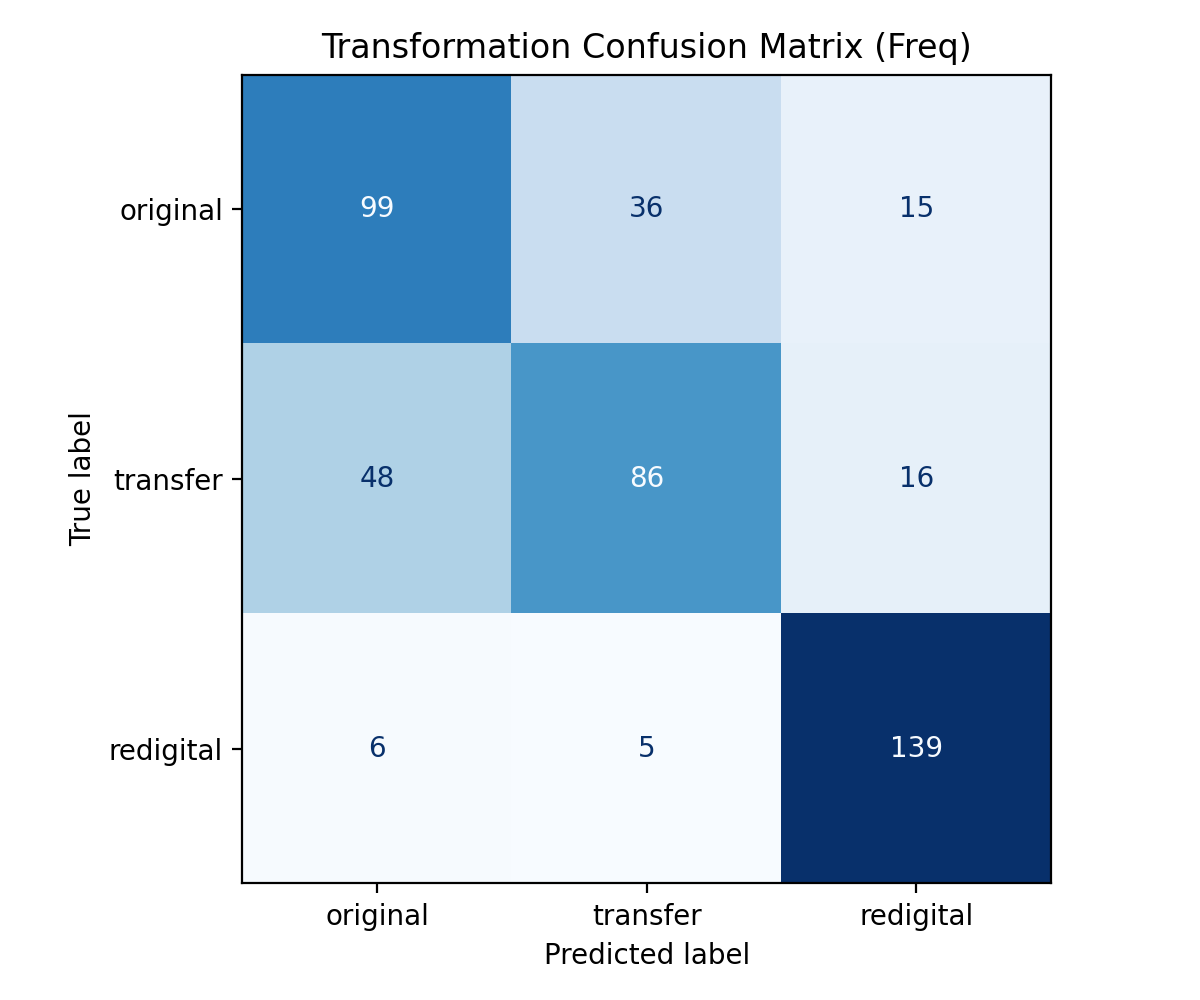

In [ ]:
show_evaluation_outputs("results/freq_aug")

**Comparison**

In [ ]:
!python src/compare_freq_agu.py

Building comparison table...

[SKIP] Missing: results/depth_frequency_1_1/metrics.json
[SKIP] Missing: results/depth_frequency_learned/metrics.json
[SKIP] Missing: results/freq_1_1/metrics.json
[SKIP] Missing: results/freq_1_2/metrics.json
[SKIP] Missing: results/freq_2_1/metrics.json
[SKIP] Missing: results/freq_learned_cosine/metrics.json
[SKIP] Missing: results/vit_rgb_fake/metrics.json
[SKIP] Missing: results/vit_rgb_multitask_1_1/metrics.json
[SKIP] Missing: results/vit_rgb_multitask_learned/metrics.json
[SKIP] Missing: results/vit_depth_frequency_1_1/metrics.json
[SKIP] Missing: results/vit_depth_frequency_learned/metrics.json
                   model fake_accuracy  ... fake_acc_transfer fake_acc_redigital
0      RGB multitask 1-2        0.9267  ...            0.9267             0.9200
1      RGB multitask 2-1        0.9244  ...            0.9200             0.9267
2  RGB multitask learned        0.9222  ...            0.9267             0.9067
3      RGB multitask 1-1        0.9

#DEPTH

After the RGB baselines, we introduce depth as an auxiliary geometric cue in the multi-task setting.

We then evaluate two variants: RGB + Depth and RGB + Depth + Edge.

The RGB + Depth model tests whether scene geometry and foreground/background structure help the two tasks, while the RGB + Depth + Edge model investigates whether inconsistencies between visual edges and depth discontinuities provide additional forensic information.

##Depth map generation
Since the dataset does not provide ground-truth depth, pseudo-depth maps are generated offline with MiDaS and paired with each RGB image to provide an additional geometric cue.

In [ ]:
!python src/generate_depth_map.py \
  --csv_paths {TRAIN_CSV} {VAL_CSV} {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --model_type MiDaS_small

Using device: cuda
Number of images to process: 3000
Loading pretrained MiDaS model: MiDaS_small
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Loading weights:  None
Using cache found in /root/.cache/torch/hub/rwightman_gen-efficientnet-pytorch_master
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master
Generating depth maps: 100% 3000/3000 [03:33<00:00, 14.07it/s]
Depth map generation completed.
Depth maps saved in: /content/drive/MyDrive/CV_Project/depth_maps


After first generation depth maps are on drive so we do not need to comute them again. If they are not on drive they are generated again. In every case the maps are loaded on local Colab memory to make loading faster

In [ ]:
from pathlib import Path

DRIVE_DEPTH_ROOT = Path("/content/drive/MyDrive/CV_Project/depth_maps")
LOCAL_DEPTH_ROOT = Path("/content/depth_maps")
DEPTH_ROOT = str(LOCAL_DEPTH_ROOT)

DRIVE_DEPTH_ROOT.mkdir(parents=True, exist_ok=True)
LOCAL_DEPTH_ROOT.mkdir(parents=True, exist_ok=True)

drive_depth_files = list(DRIVE_DEPTH_ROOT.rglob("*.npy"))

print(f"Depth maps found on Drive: {len(drive_depth_files)}")

if len(drive_depth_files) == 0:
    print("No depth maps found on Drive. Generating them once and saving directly to Drive...")

    !python src/generate_depth_map.py \
      --csv_paths {TRAIN_CSV} {VAL_CSV} {TEST_CSV} \
      --image_root {IMAGE_ROOT} \
      --depth_root "{DRIVE_DEPTH_ROOT}" \
      --model_type MiDaS_small

else:
    print("Depth maps already exist on Drive. No need to regenerate them.")

print("Copying depth maps from Drive to local /content...")
!rsync -a --info=progress2 "{DRIVE_DEPTH_ROOT}/" "{LOCAL_DEPTH_ROOT}/"

DEPTH_ROOT = str(LOCAL_DEPTH_ROOT)

print("Local DEPTH_ROOT:", DEPTH_ROOT)
print("Some local depth maps:")
!find "{DEPTH_ROOT}" -type f -name "*.npy" | head

Depth maps found on Drive: 3000
Depth maps already exist on Drive. No need to regenerate them.
Copying depth maps from Drive to local /content...
 15,795,119,360 100%  118.29MB/s    0:02:07 (xfr#3000, to-chk=0/3010)
Local DEPTH_ROOT: /content/depth_maps
Some local depth maps:
/content/depth_maps/original/real/real_002708.npy
/content/depth_maps/original/real/real_001837.npy
/content/depth_maps/original/real/real_008499.npy
/content/depth_maps/original/real/real_006372.npy
/content/depth_maps/original/real/real_009154.npy
/content/depth_maps/original/real/real_004017.npy
/content/depth_maps/original/real/real_008003.npy
/content/depth_maps/original/real/real_003040.npy
/content/depth_maps/original/real/real_006963.npy
/content/depth_maps/original/real/real_008393.npy


##RGB + Depth

This model combines RGB images with precomputed MiDaS depth maps. RGB features provide visual appearance information, while depth features add geometric cues about scene structure and spatial consistency.

The fused representation is then used in a multi-task setting for both real/fake detection and transformation classification.

In [ ]:
!python src/train_depth.py \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint_name best_depth_uncertainty.pt \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lr {LEARNING_RATE} \
  --use_uncertainty_weighting \
  --no_edge

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100% 44.7M/44.7M [00:00<00:00, 202MB/s]

Epoch 1/10
Training geometric: 100% 66/66 [01:39<00:00,  1.51s/it]
Validation geometric: 100% 15/15 [00:27<00:00,  1.82s/it]
Train: {'loss': 1.4335606926963442, 'fake_acc': 0.8428571428571429, 'transform_acc': 0.4076190476190476, 'weight_fake': 1.0035521388053894, 'weight_transform': 0.9972396520051089}
Val:   {'loss': 1.1427645081943936, 'fake_acc': 0.8911111111111111, 'transform_acc': 0.5733333333333334}
Val score: 0.7322
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_depth_uncertainty.pt

Epoch 2/10
Training geometric: 100% 66/66 [01:40<00:00,  1.52s/it]
Validation geometric: 100% 15/15 [00:26<00:00,  1.74s/it]
Train: {'loss': 0.8693801720937093, 'fake_acc': 0.9704761904761905, 'transform_acc': 0.5876190476190476, 'weight_fake': 1.011453305229996, 'weight_transform': 0.99923

##Evaluate RGB + Depth

In [ ]:
!python src/evaluate_depth.py \
  --task multitask \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_uncertainty.pt \
  --output_dir results/depth_only \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --no_edge

Selected task: multitask
Using device: cuda

Evaluation results
Fake accuracy:        0.9178
Fake F1 macro:        0.9175

Fake accuracy by transformation:
  original: 0.9133
  transfer: 0.9200
  redigital: 0.9200
Transform accuracy:   0.7689
Transform F1 macro:   0.7695

Saved results in:
results/depth_only


Evaluation metrics


,Metric,Group,Value
0,fake_accuracy,-,0.9178
1,fake_f1_macro,-,0.9175
2,fake_accuracy_by_transform,original,0.9133
3,fake_accuracy_by_transform,transfer,0.9200
4,fake_accuracy_by_transform,redigital,0.9200
5,transform_accuracy,-,0.7689
6,transform_f1_macro,-,0.7695



Real/Fake confusion matrix


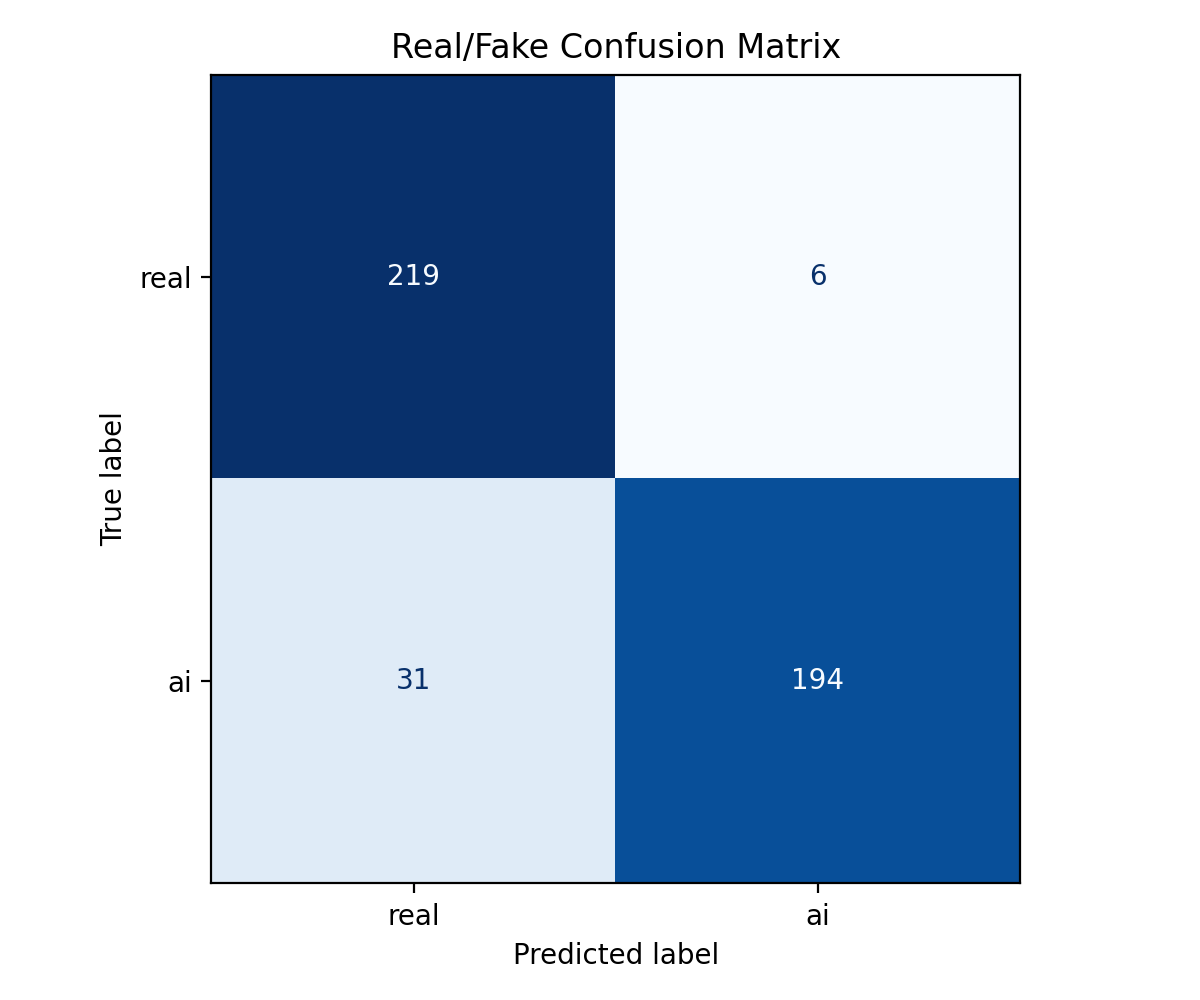


Transformation confusion matrix


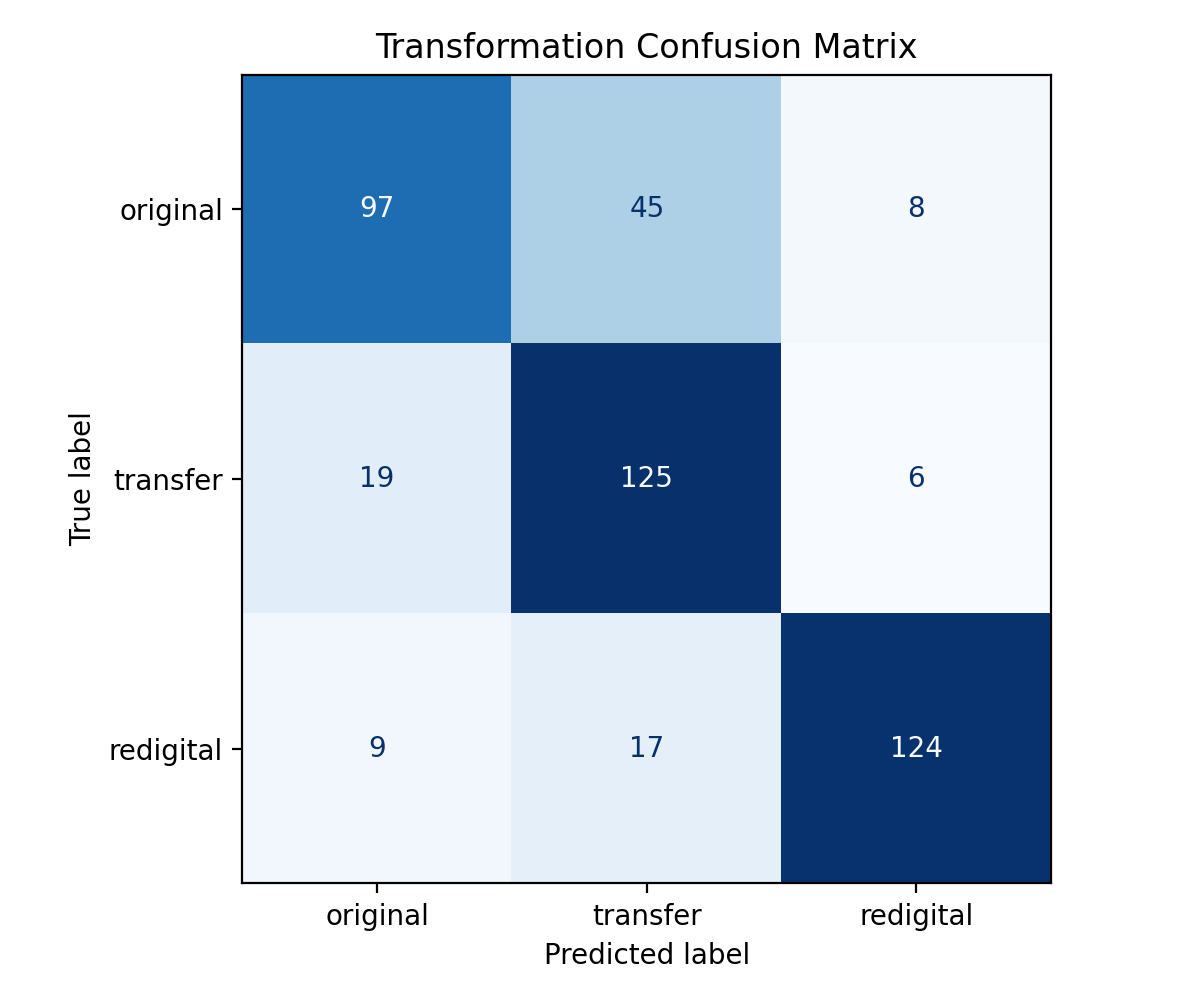

In [ ]:
show_evaluation_outputs("results/depth_only")

Compared to the RGB fake baseline, the RGB + Depth model slightly improves real/fake detection, suggesting that depth information can provide useful geometric cues in more challenging post-processing conditions.

##RGB + Depth + Edge

This model extends RGB + Depth by adding an edge-consistency map as an additional input. The edge map is computed by comparing RGB image edges with depth-map edges, in order to highlight possible inconsistencies between visual contours and estimated geometry.


In [ ]:
!python src/train_depth.py \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint_name best_depth_edge_uncertainty.pt \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lr {LEARNING_RATE} \
  --use_uncertainty_weighting

Using device: cuda

Epoch 1/10
Training geometric: 100% 66/66 [01:39<00:00,  1.50s/it]
Validation geometric: 100% 15/15 [00:25<00:00,  1.72s/it]
Train: {'loss': 1.4295722282500494, 'fake_acc': 0.8466666666666667, 'transform_acc': 0.4147619047619048, 'weight_fake': 1.0035531701463642, 'weight_transform': 0.997207064520229}
Val:   {'loss': 1.0742383522457546, 'fake_acc': 0.9044444444444445, 'transform_acc': 0.5755555555555556}
Val score: 0.7400
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_depth_edge_uncertainty.pt

Epoch 2/10
Training geometric: 100% 66/66 [01:39<00:00,  1.50s/it]
Validation geometric: 100% 15/15 [00:25<00:00,  1.70s/it]
Train: {'loss': 0.8439805281729925, 'fake_acc': 0.960952380952381, 'transform_acc': 0.6061904761904762, 'weight_fake': 1.011484783707243, 'weight_transform': 0.9997708598772684}
Val:   {'loss': 0.9987333407335811, 'fake_acc': 0.9133333333333333, 'transform_acc': 0.68}
Val score: 0.7967
Learning rate: 0.000100
Saved best checkpoint to

##Evaluate RGB+Depth+edge

In [ ]:
!python src/evaluate_depth.py \
  --task multitask \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_edge_uncertainty.pt \
  --output_dir results/depth_edge \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Selected task: multitask
Using device: cuda

Evaluation results
Fake accuracy:        0.9244
Fake F1 macro:        0.9244

Fake accuracy by transformation:
  original: 0.9333
  transfer: 0.9267
  redigital: 0.9133
Transform accuracy:   0.7244
Transform F1 macro:   0.7069

Saved results in:
results/depth_edge


Evaluation metrics


,Metric,Group,Value
0,fake_accuracy,-,0.9244
1,fake_f1_macro,-,0.9244
2,fake_accuracy_by_transform,original,0.9333
3,fake_accuracy_by_transform,transfer,0.9267
4,fake_accuracy_by_transform,redigital,0.9133
5,transform_accuracy,-,0.7244
6,transform_f1_macro,-,0.7069



Real/Fake confusion matrix


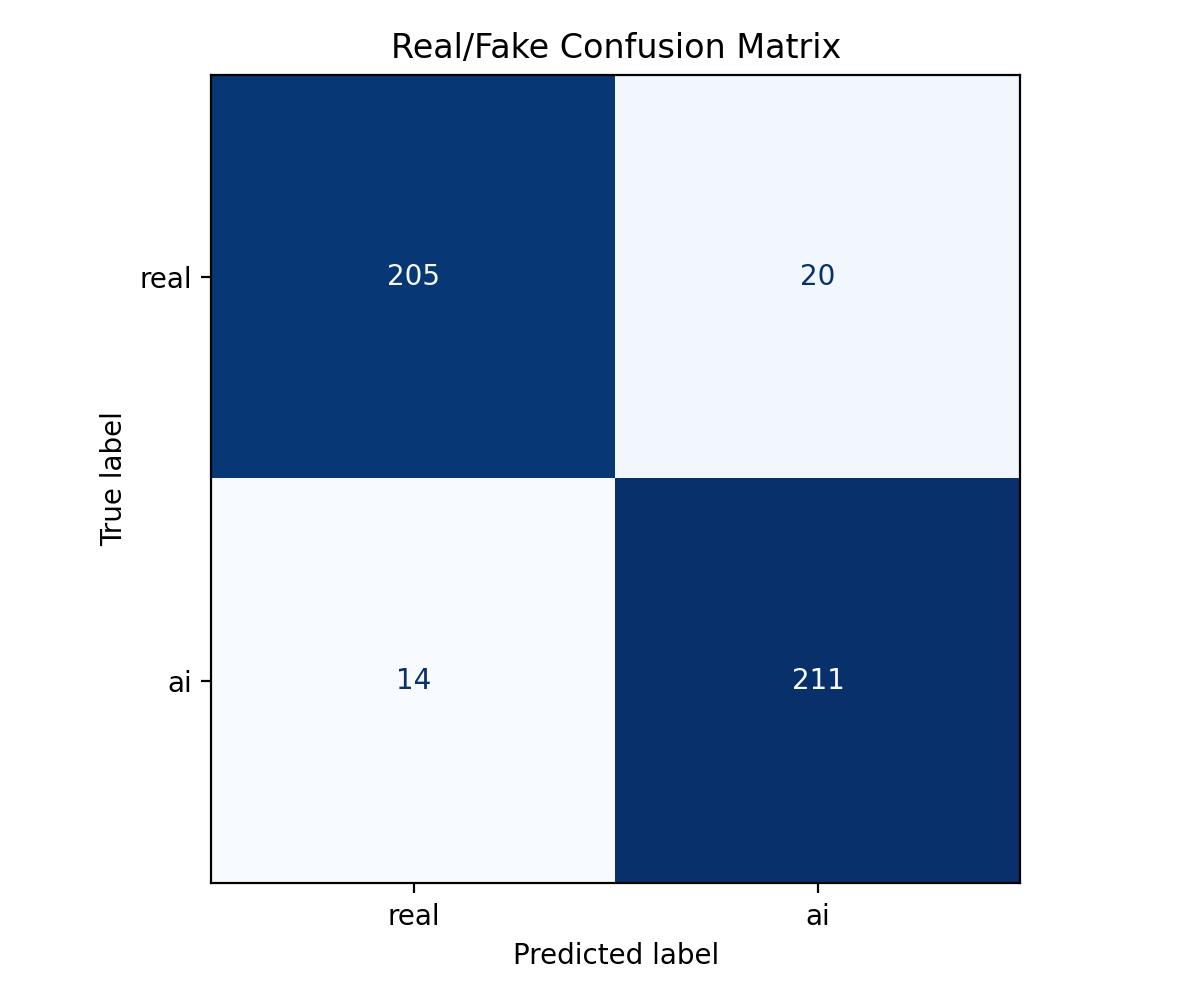


Transformation confusion matrix


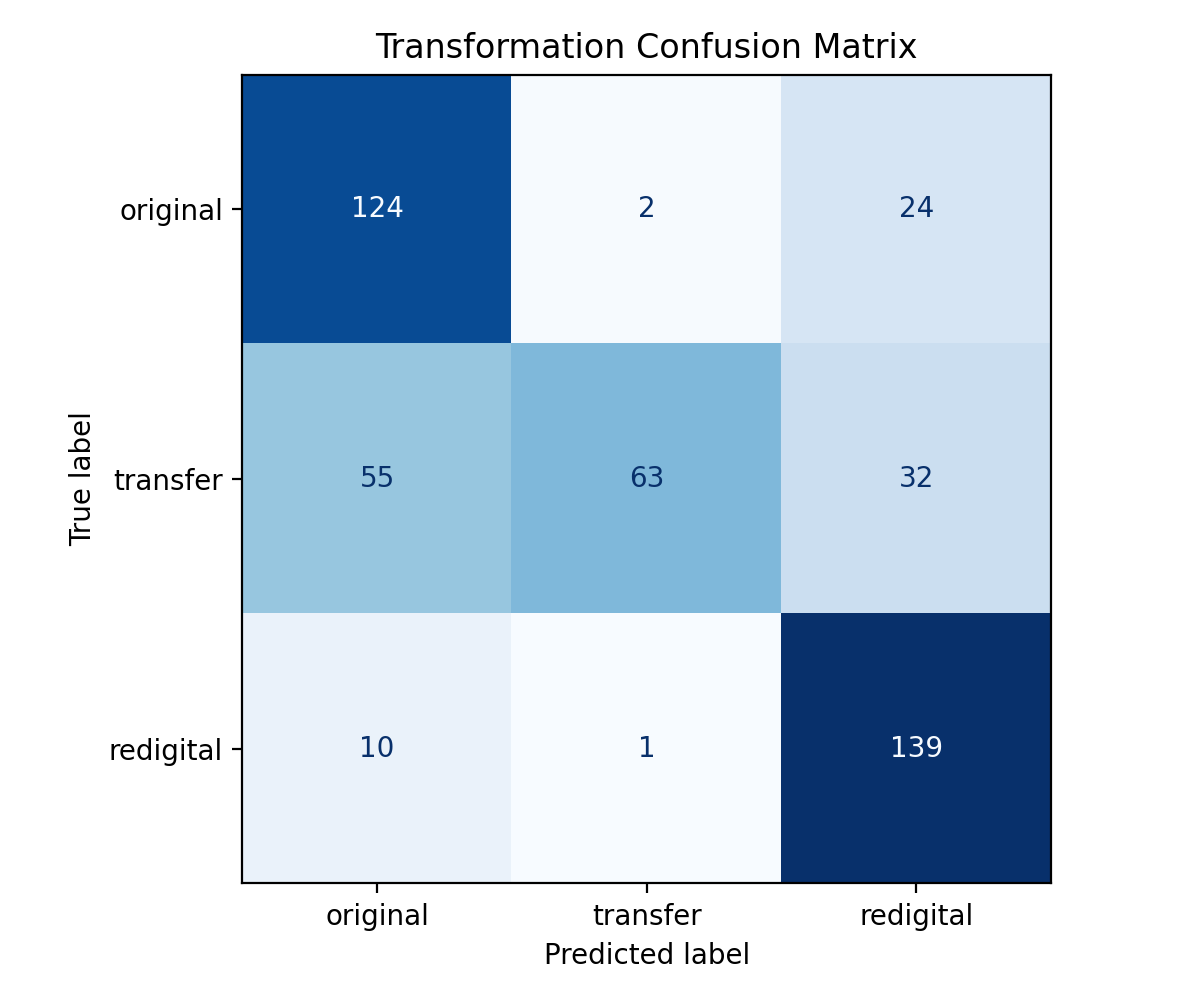

In [ ]:
show_evaluation_outputs("results/depth_edge")

The edge-consistency branch introduces additional geometric information, but also increases model complexity. This leads to mild overfitting and a small decrease in real/fake validation accuracy, although transformation classification slightly improves.
We should use only depth without edge

##Comparison
We compare RGB + Depth with RGB + Depth + Edge

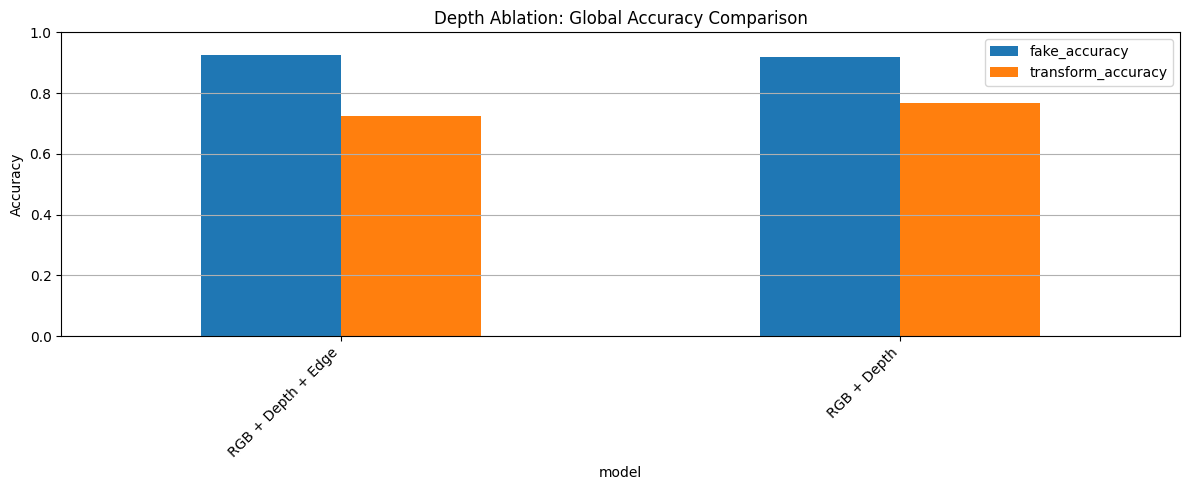

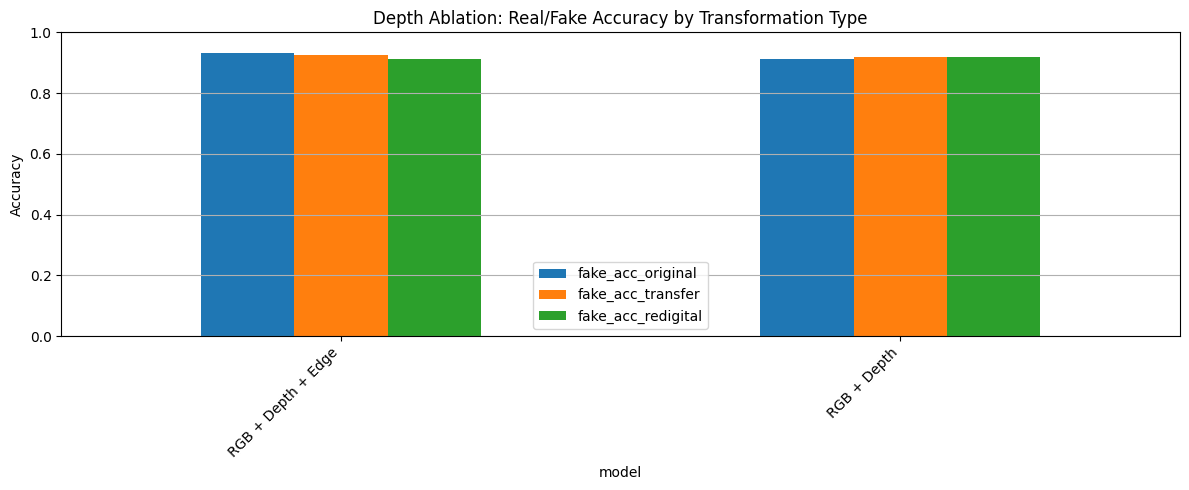

In [ ]:
depth_results = {
    "RGB + Depth": "results/depth_only/metrics.json",
    "RGB + Depth + Edge": "results/depth_edge/metrics.json",
}

depth_comparison_df = build_comparison_df(depth_results)

depth_comparison_df


plot_global_accuracy(
    depth_comparison_df,
    "Depth Ablation: Global Accuracy Comparison"
)



plot_fake_accuracy_by_transformation(
    depth_comparison_df,
    "Depth Ablation: Real/Fake Accuracy by Transformation Type"
)




#RGB + DEPTH + FREQUENCY

This model combines three complementary cues: RGB appearance, MiDaS pseudo-depth maps, and frequency-domain information computed from the RGB image.

Depth provides geometric information about scene structure, while frequency features can highlight spectral artifacts related to image generation, compression, transmission, or re-digitization. The three representations are fused and used in a multi-task setting for both real/fake detection and transformation classification.

In [ ]:
!python src/train_depth_frequency.py \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint_name best_depth_frequency_uncertainty.pt \
  --checkpoint_dir checkpoints \
  --epochs {EPOCHS} \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lr {LEARNING_RATE} \
  --use_uncertainty_weighting

Using device: cuda

Epoch 1/10
Training RGB+Depth+Frequency: 100% 66/66 [01:33<00:00,  1.42s/it]
Validation RGB+Depth+Frequency: 100% 15/15 [00:25<00:00,  1.73s/it]
Train: {'loss': 1.4007886595953079, 'fake_acc': 0.8447619047619047, 'transform_acc': 0.43857142857142856, 'weight_fake': 1.0035327402028171, 'weight_transform': 0.9976693861412279}
Val:   {'loss': 1.0587247247166103, 'fake_acc': 0.9066666666666666, 'transform_acc': 0.5488888888888889, 'weight_fake': 1.0074365139007568, 'weight_transform': 0.9976649880409241}
Val score: 0.7278
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_depth_frequency_uncertainty.pt

Epoch 2/10
Training RGB+Depth+Frequency: 100% 66/66 [01:35<00:00,  1.45s/it]
Validation RGB+Depth+Frequency: 100% 15/15 [00:25<00:00,  1.73s/it]
Train: {'loss': 0.8302018139475867, 'fake_acc': 0.9580952380952381, 'transform_acc': 0.6161904761904762, 'weight_fake': 1.0114180301174973, 'weight_transform': 1.0022940283471888}
Val:   {'loss': 0.998453268210093

##Evaluate RGB + DEPTH + FREQUENCY

In [ ]:
!python src/evaluation_depth_frequency.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_frequency_uncertainty.pt \
  --output_dir results/depth_frequency_uncertainty \
  --batch_size {BATCH_SIZE} \
  --image_size  {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Using device: cuda
Evaluating RGB+Depth+Frequency: 100% 15/15 [00:21<00:00,  1.46s/it]

Evaluation results
------------------
Fake accuracy:        0.9089
Fake F1 macro:        0.9089
Fake accuracy by transformation:
  original: 0.9133
  transfer: 0.9200
  redigital: 0.8933
Transform accuracy:   0.7778
Transform F1 macro:   0.7747

Saved results in: results/depth_frequency_uncertainty


Evaluation metrics


,Metric,Group,Value
0,fake_accuracy,-,0.9089
1,fake_f1_macro,-,0.9089
2,fake_accuracy_by_transform,original,0.9133
3,fake_accuracy_by_transform,transfer,0.9200
4,fake_accuracy_by_transform,redigital,0.8933
5,transform_accuracy,-,0.7778
6,transform_f1_macro,-,0.7747
7,fake_classification_report,real,"{'precision': 0.9181818181818182, 'recall': 0...."
8,fake_classification_report,fake,"{'precision': 0.9, 'recall': 0.92, 'f1-score':..."
9,fake_classification_report,accuracy,0.9089



Real/Fake confusion matrix


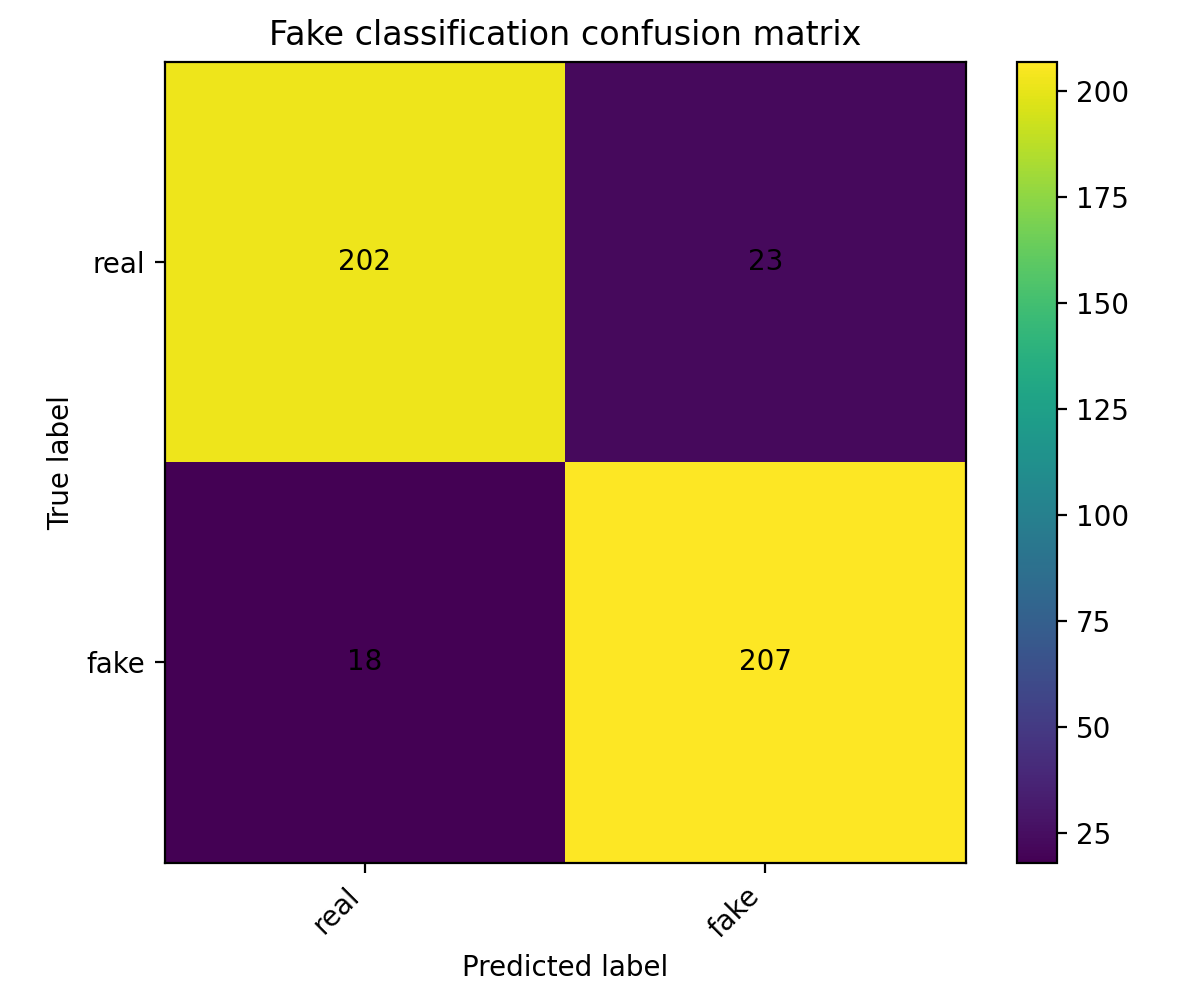


Transformation confusion matrix


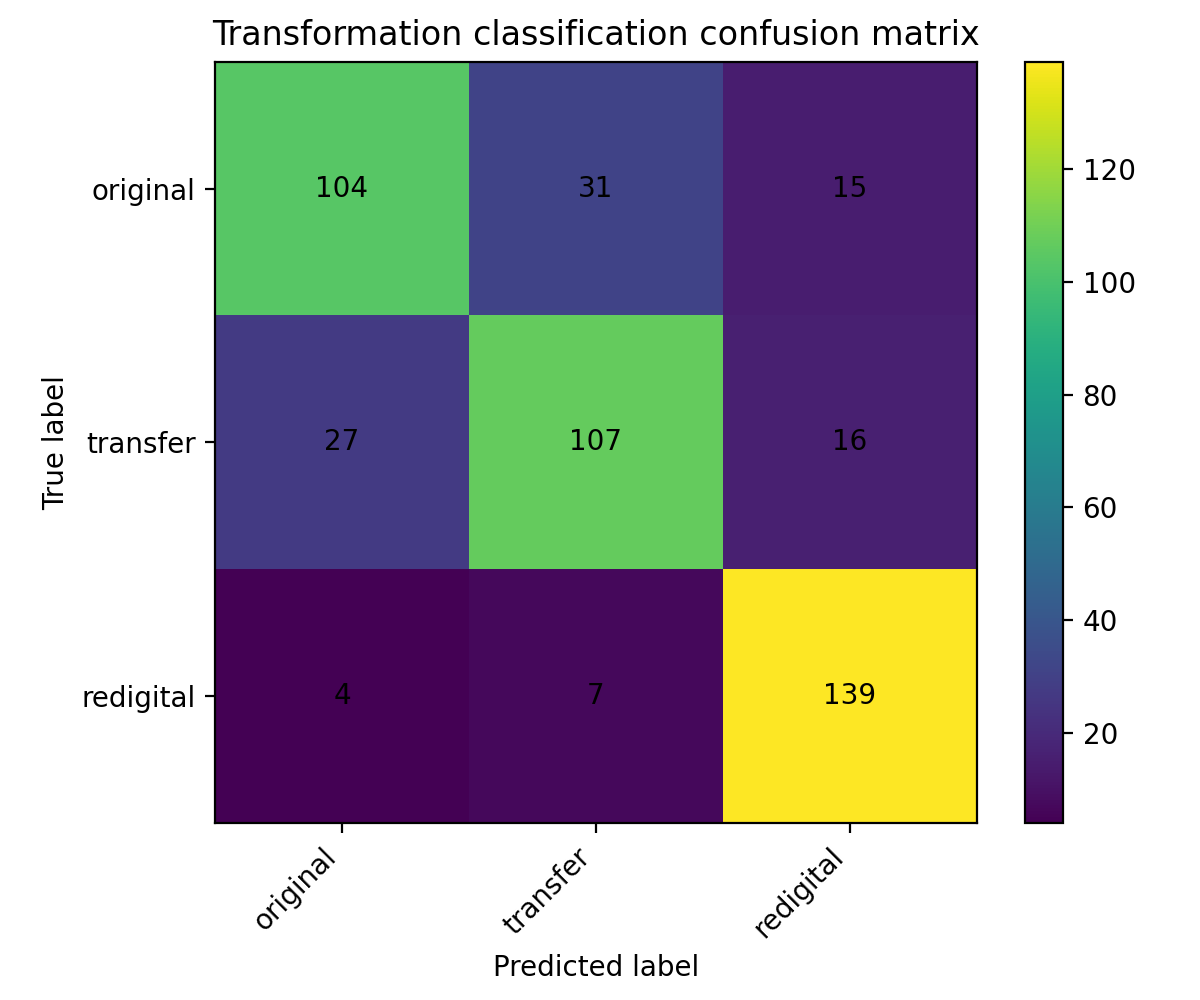

In [ ]:
show_evaluation_outputs("results/depth_frequency_uncertainty")

Adding frequency module to depth module improves transformation classification. This suggests that spectral cues are useful for detecting post-processing traces, although they do not provide a consistent benefit for real/fake detection.

#RGB + Depth + Frequency gated

This model introduces a gated fusion mechanism on top of the RGB + Depth + Frequency architecture.

The gate learns how much weight to assign to RGB, depth, and frequency separately for each task. This allows the fake detection head and the transformation classification head to use different modality combinations.

This experiment tests whether task-specific fusion improves performance compared to the shared non-gated multimodal representation.

In [ ]:
DRIVE_CHECKPOINT_DIR = "/content/drive/MyDrive/CV_Project/checkpoints"

In [ ]:
!python src/train_depth_frequency_gated.py \
  --train_csv {TRAIN_CSV} \
  --val_csv {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint_name best_depth_frequency_gated_uncertainty.pt \
  --checkpoint_dir checkpoints \
  --epochs 10 \
  --batch_size {BATCH_SIZE} \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --lr {LEARNING_RATE} \
  --use_uncertainty_weighting

Using device: cuda

Epoch 1/10
Training RGB+Depth+Frequency: 100% 66/66 [01:41<00:00,  1.54s/it]
Validation RGB+Depth+Frequency: 100% 15/15 [00:26<00:00,  1.78s/it]
Train: {'loss': 1.483180627822876, 'fake_acc': 0.809047619047619, 'transform_acc': 0.4204761904761905, 'weight_fake': 1.0035513639450073, 'weight_transform': 0.9971530374252435}
Val:   {'loss': 1.1383898083368937, 'fake_acc': 0.9111111111111111, 'transform_acc': 0.5355555555555556, 'weight_fake': 1.007663607597351, 'weight_transform': 0.9956599473953247}
Val score: 0.7233
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_depth_frequency_gated_uncertainty.pt

Epoch 2/10
Training RGB+Depth+Frequency: 100% 66/66 [01:40<00:00,  1.52s/it]
Validation RGB+Depth+Frequency: 100% 15/15 [00:27<00:00,  1.81s/it]
Train: {'loss': 0.8764823752357846, 'fake_acc': 0.9709523809523809, 'transform_acc': 0.5885714285714285, 'weight_fake': 1.0118055506186052, 'weight_transform': 1.0000201707536525}
Val:   {'loss': 1.0599855232238

##Evaluation RGB + DEPTH + FREQUENCY GATED

In [ ]:
!python src/evaluate_depth_frequency_gated.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_frequency_gated_uncertainty.pt \
  --output_dir results/depth_frequency_gated_uncertainty \
  --batch_size {BATCH_SIZE} \
  --image_size  {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}


Using device: cuda
Evaluating RGB+Depth+Frequency: 100% 15/15 [00:21<00:00,  1.41s/it]

Evaluation results
------------------
Fake accuracy:        0.9156
Fake F1 macro:        0.9154
Fake accuracy by transformation:
  original: 0.9333
  transfer: 0.9067
  redigital: 0.9067
Transform accuracy:   0.7600
Transform F1 macro:   0.7483

Saved results in: results/depth_frequency_gated_uncertainty


Evaluation metrics


,Metric,Group,Value
0,fake_accuracy,-,0.9156
1,fake_f1_macro,-,0.9154
2,fake_accuracy_by_transform,original,0.9333
3,fake_accuracy_by_transform,transfer,0.9067
4,fake_accuracy_by_transform,redigital,0.9067
5,transform_accuracy,-,0.7600
6,transform_f1_macro,-,0.7483
7,fake_classification_report,real,"{'precision': 0.8816326530612245, 'recall': 0...."
8,fake_classification_report,fake,"{'precision': 0.9560975609756097, 'recall': 0...."
9,fake_classification_report,accuracy,0.9156



Real/Fake confusion matrix


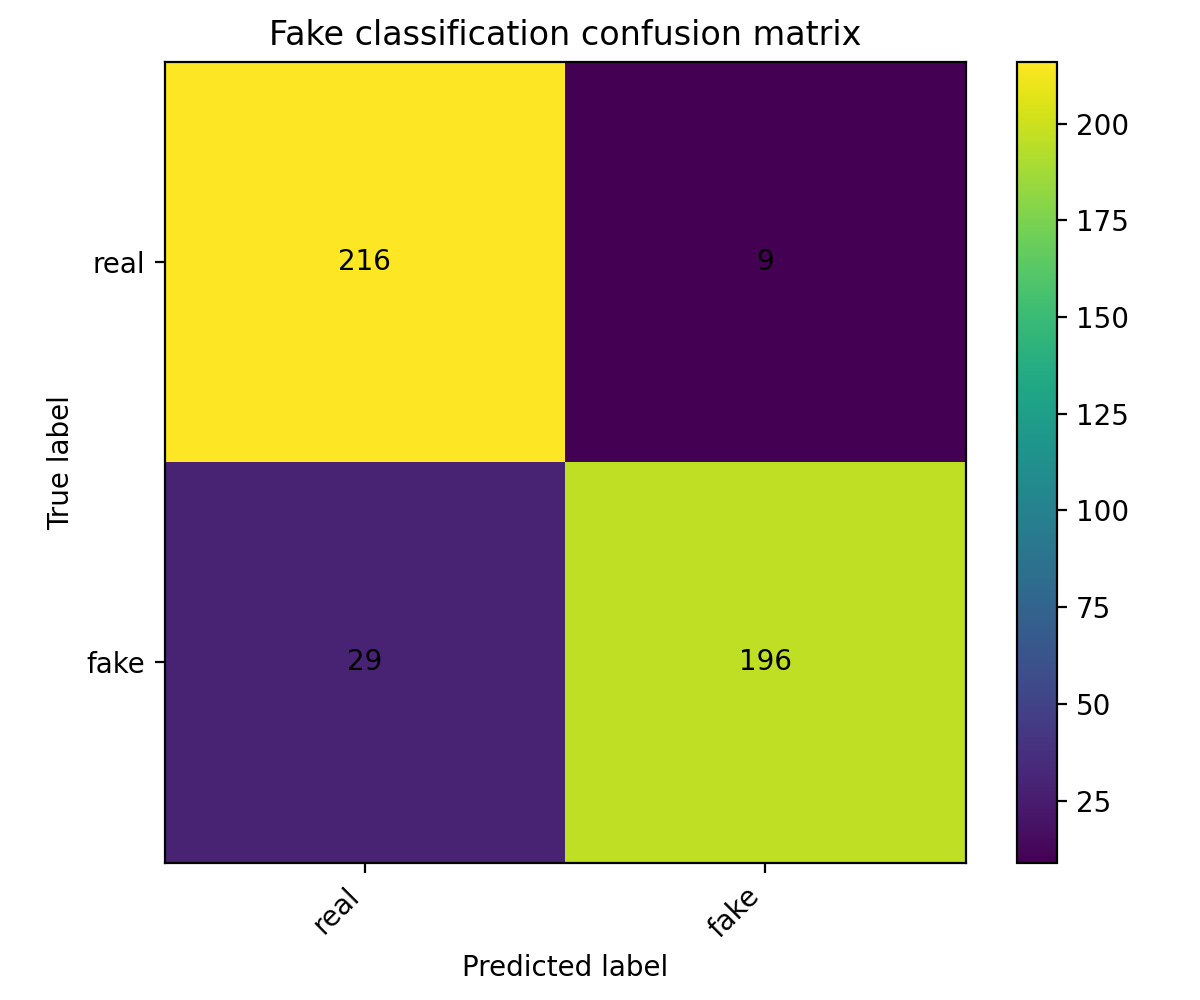


Transformation confusion matrix


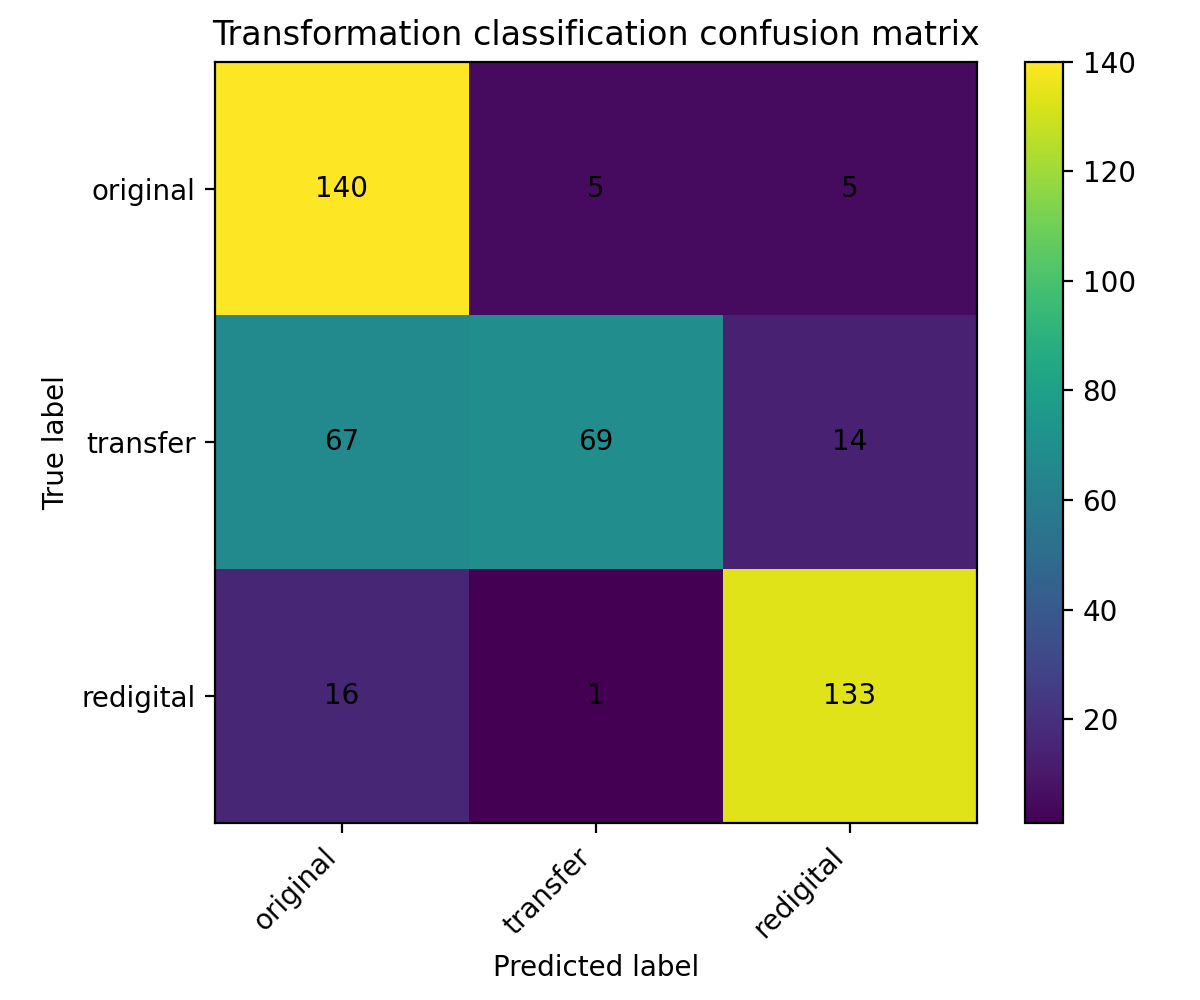

In [ ]:
show_evaluation_outputs("results/depth_frequency_gated_uncertainty")

Gated fusion does not improve the overall performance: fake accuracy slightly increases, but transformation accuracy decreases, leading to a lower final score than the non-gated model.

#Comparison
We do the comparison betweeen RGB + Depth + Frequency and RGB + Depth + Frequency Gated

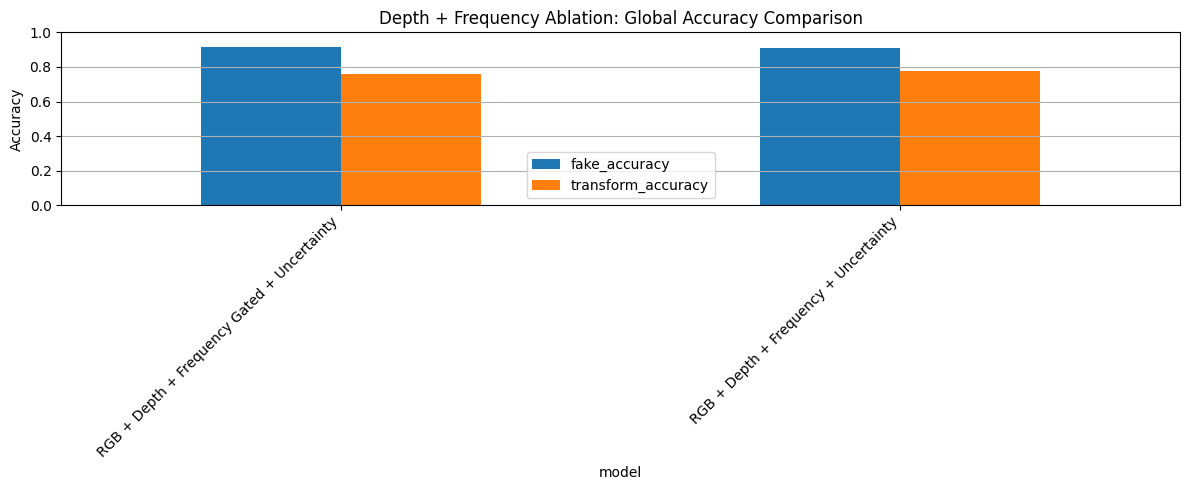

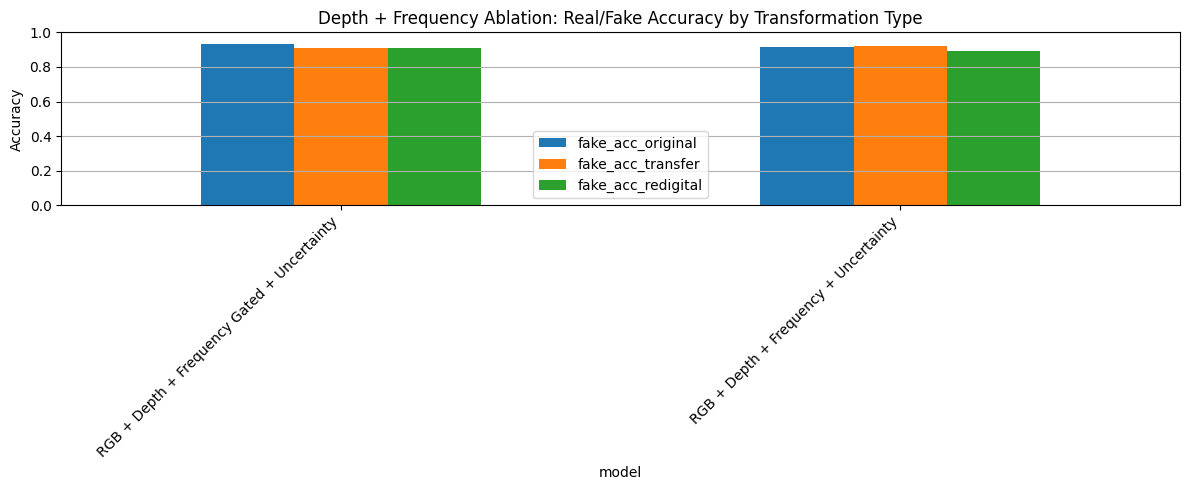

In [ ]:
depth_frequency_results = {
    "RGB+Depth+Frequency": "results/depth_frequency_uncertainty/metrics.json",
    "RGB+Depth+Frequency Gated": "results/depth_frequency_gated_uncertainty/metrics.json",
}

depth_frequency_comparison_df = build_comparison_df(depth_frequency_results)

depth_frequency_comparison_df

plot_global_accuracy(
    depth_frequency_comparison_df,
    "Depth + Frequency Ablation: Global Accuracy Comparison"
)


plot_fake_accuracy_by_transformation(
    depth_frequency_comparison_df,
    "Depth + Frequency Ablation: Real/Fake Accuracy by Transformation Type"
)

#Grad-CAM
Since RGB + Depth was more promising than RGB + Depth + Edge, we applied Grad-CAM to this model. Almost same reasoning is done with models with depth and frequency. The non-gated model was more promising so we applied Grad-CAM on it. Grad-CAM helps visualize the image regions that most influence the prediction, providing a qualitative interpretation of the model behavior.

##RGB + DEPTH visualization

In [ ]:
!python src/gradCam_depth.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_edge_uncertainty.pt \
  --output_dir results/gradcam_depth \
  --task fake \
  --target predicted \
  --max_images 1 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --fake_filter 0 \
  --shuffle

In [ ]:
!python src/gradCam_depth.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_edge_uncertainty.pt \
  --output_dir results/gradcam_depth \
  --task fake \
  --target predicted \
  --max_images 1 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --fake_filter 1 \
  --shuffle

In [ ]:
!python src/gradCam_depth.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_edge_uncertainty.pt \
  --output_dir results/gradcam_depth \
  --task transform \
  --target predicted \
  --max_images 1 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --transform_filter 0 \
  --shuffle

In [ ]:
!python src/gradCam_depth.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_edge_uncertainty.pt \
  --output_dir results/gradcam_depth \
  --task transform \
  --target predicted \
  --max_images 1 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --transform_filter 1 \
  --shuffle

In [ ]:
!python src/gradCam_depth.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_edge_uncertainty.pt \
  --output_dir results/gradcam_depth \
  --task transform \
  --target predicted \
  --max_images 1 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --transform_filter 2 \
  --shuffle

In [ ]:
#Display Grad-Cam
from IPython.display import Image, display
from pathlib import Path

gradcam_dir = Path("results/gradcam_depth")

for img_path in sorted(gradcam_dir.glob("*.png")):
    print(img_path.name)
    display(Image(filename=str(img_path)))

##RGB + DEPTH + FREQUENCY visualization

In [ ]:
!python src/gradcam_depth_frequency_gated.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_frequency_gated_uncertainty.pt \
  --output_dir results/gradcam_depth_frequency \
  --task fake \
  --target predicted \
  --max_images 1 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --fake_filter 0 \
  --shuffle


In [ ]:
!python src/gradcam_depth_frequency_gated.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_frequency_gated_uncertainty.pt \
  --output_dir results/gradcam_depth_frequency \
  --task fake \
  --target predicted \
  --max_images 1 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --fake_filter 1 \
  --shuffle


In [ ]:
!python src/gradcam_depth_frequency_gated.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_frequency_gated_uncertainty.pt \
  --output_dir results/gradcam_depth_frequency \
  --task transform \
  --target predicted \
  --max_images 1 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --transform_filter 0 \
  --shuffle



In [ ]:
!python src/gradcam_depth_frequency_gated.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_frequency_gated_uncertainty.pt \
  --output_dir results/gradcam_depth_frequency \
  --task transform \
  --target predicted \
  --max_images 1 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --transform_filter 1 \
  --shuffle



In [ ]:
!python src/gradcam_depth_frequency_gated.py \
  --csv_path {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_depth_frequency_gated_uncertainty.pt \
  --output_dir results/gradcam_depth_frequency \
  --task transform \
  --target predicted \
  --max_images 1 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS} \
  --transform_filter 2 \
  --shuffle

In [ ]:
#Display Grad-Cam
from IPython.display import Image, display
from pathlib import Path

gradcam_dir = Path("results/gradcam_depth_frequency")

for img_path in sorted(gradcam_dir.glob("*.png")):
    print(img_path.name)
    display(Image(filename=str(img_path)))

#ViT
We try to use different method for training to evaluate if there are some improvements.
In particular we decide to apply ViT for the most performant method of RGB baseline (lamda_fake=1.0 lamda_transform=2.0), for the frequency and for frequency-rgb-depth.

##ViT RGB

**Train**

In [ ]:
!python src/train_vit_RGB_1_2.py \
  --train_csv  {TRAIN_CSV} \
  --val_csv    {VAL_CSV} \
  --image_root {IMAGE_ROOT} \
  --epochs     {EPOCHS} \
  --batch_size 16 \
  --num_workers {NUM_WORKERS} \
  --checkpoint_name best_vit_rgb_multitask_1_2.pt

Task:           multitask
ViT model:      vit_small_patch16_224
lambda_fake:    1.0
lambda_transform: 1.0
Loss weighting: manual
Using device:   cuda
model.safetensors: 100% 88.2M/88.2M [00:01<00:00, 48.2MB/s]

Epoch 1/10
Training ViT-RGB 1-2: 100% 132/132 [00:46<00:00,  2.87it/s]
Validation ViT-RGB 1-2: 100% 29/29 [00:11<00:00,  2.61it/s]
Train: {'loss': 1.61415817402658, 'fake_acc': 0.7847619047619048, 'transform_acc': 0.4766666666666667}
Val:   {'loss': 1.0346809069315592, 'fake_acc': 0.8755555555555555, 'transform_acc': 0.6822222222222222}
Val score:     0.7789
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_vit_rgb_multitask_1_2.pt

Epoch 2/10
Training ViT-RGB 1-2: 100% 132/132 [00:45<00:00,  2.91it/s]
Validation ViT-RGB 1-2: 100% 29/29 [00:11<00:00,  2.55it/s]
Train: {'loss': 0.7799960152591978, 'fake_acc': 0.9352380952380952, 'transform_acc': 0.729047619047619}
Val:   {'loss': 0.6800728244582812, 'fake_acc': 0.9177777777777778, 'transform_acc': 0.79555555555555

**Evalutation**

In [ ]:
!python src/evaluate_vit_RGB.py \
  --csv_path   {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --checkpoint checkpoints/best_vit_rgb_multitask_1_2.pt \
  --output_dir results/vit_rgb_multitask_1_2.pt\
  --batch_size 16 \
  --image_size {IMAGE_SIZE} \
  --num_workers {NUM_WORKERS}

Selected task: multitask
Using device:  cuda

Evaluation results — ViT-RGB model
Fake accuracy:        0.9356
Fake F1 macro:        0.9356

Fake accuracy by transformation:
  original: 0.9400
  transfer: 0.9267
  redigital: 0.9400
Transform accuracy:   0.8622
Transform F1 macro:   0.8624

Saved results in: results/vit_rgb_multitask_1_2.pt


**Results**

In [ ]:
show_evaluation_outputs("results/vit_multitask_1_1")

Metrics file not found: results/vit_multitask_1_1/metrics.json


##ViT RGBs+Frequency+Depth

**PreTrain**

In [ ]:
import pandas as pd
from pathlib import Path

def filter_csv_by_depth(csv_path, depth_root, output_csv):
    df         = pd.read_csv(csv_path)
    depth_root = Path(depth_root)

    mask = df["image_path"].apply(
        lambda p: (depth_root / Path(p).with_suffix(".npy")).exists()
    )

    df_filtered = df[mask].reset_index(drop=True)
    df_filtered.to_csv(output_csv, index=False)

    print(f"[{Path(csv_path).name}]")
    print(f"  Originale: {len(df)} righe")
    print(f"  Filtrato:  {len(df_filtered)} righe")
    print(f"  Rimosse:   {len(df) - len(df_filtered)} senza depth map")
    print()
    return df_filtered


filter_csv_by_depth(TRAIN_CSV, DEPTH_ROOT, "data/splits/train_depth.csv")
filter_csv_by_depth(VAL_CSV,   DEPTH_ROOT, "data/splits/val_depth.csv")
filter_csv_by_depth(TEST_CSV,  DEPTH_ROOT, "data/splits/test_depth.csv")

[train_balanced.csv]
  Originale: 2100 righe
  Filtrato:  2100 righe
  Rimosse:   0 senza depth map

[val_balanced.csv]
  Originale: 450 righe
  Filtrato:  450 righe
  Rimosse:   0 senza depth map

[test_balanced.csv]
  Originale: 450 righe
  Filtrato:  450 righe
  Rimosse:   0 senza depth map



,image_path,fake_label,transform_label,category,transform_name,fake_name
0,original/real/real_002884.jpg,0,0,unknown,original,real
1,original/real/real_005783.jpg,0,0,unknown,original,real
2,original/real/real_008017.jpg,0,0,unknown,original,real
3,original/real/real_006200.jpg,0,0,unknown,original,real
4,original/real/real_006053.jpg,0,0,unknown,original,real
...,...,...,...,...,...,...
445,redigital/ai/redigital_War_&_Conflict_Scenes_0...,1,2,War_&_Conflict_Scenes,redigital,ai
446,redigital/ai/redigital_Natural_Disasters_&_Acc...,1,2,Natural_Disasters_&_Accidents,redigital,ai
447,redigital/ai/redigital_Natural_Disasters_&_Acc...,1,2,Natural_Disasters_&_Accidents,redigital,ai
448,redigital/ai/redigital_War_&_Conflict_Scenes_0...,1,2,War_&_Conflict_Scenes,redigital,ai


**ReName**

In [ ]:
TRAIN_CSV_DEPTH = "data/splits/train_depth.csv"
VAL_CSV_DEPTH   = "data/splits/val_depth.csv"
TEST_CSV_DEPTH  = "data/splits/test_depth.csv"

**Train**

In [ ]:
!python src/train_vit_depth_frequency_1_2.py \
  --train_csv  {TRAIN_CSV_DEPTH} \
  --val_csv    {VAL_CSV_DEPTH} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --epochs     {EPOCHS} \
  --batch_size 16 \
  --num_workers 0 \
  --checkpoint_name best_vit_depth_freq_multitask_1_2.pt

ViT model:        vit_small_patch16_224
lambda_fake:      1.0
lambda_transform: 1.0
Uncertainty LW:   False
Using device:     cuda

Epoch 1/10
Training ViT+D+F 1-2: 100% 132/132 [02:19<00:00,  1.06s/it]
Validation ViT+D+F 1-2: 100% 29/29 [00:32<00:00,  1.13s/it]
Train: {'loss': 1.2667534648804437, 'fake_acc': 0.8557142857142858, 'transform_acc': 0.49952380952380954}
Val:   {'loss': 1.0587512392467922, 'fake_acc': 0.8955555555555555, 'transform_acc': 0.5866666666666667}
Val score:     0.7411
Learning rate: 0.000100
Saved best checkpoint to checkpoints/best_vit_depth_freq_multitask_1_2.pt

Epoch 2/10
Training ViT+D+F 1-2: 100% 132/132 [02:19<00:00,  1.06s/it]
Validation ViT+D+F 1-2: 100% 29/29 [00:33<00:00,  1.16s/it]
Train: {'loss': 0.7393001207851229, 'fake_acc': 0.9623809523809523, 'transform_acc': 0.7014285714285714}
Val:   {'loss': 0.9075965280003018, 'fake_acc': 0.9, 'transform_acc': 0.7133333333333334}
Val score:     0.8067
Learning rate: 0.000100
Saved best checkpoint to checkpoi

**Evaluate**

In [ ]:
!python src/evaluate_vit_depth_frequency.py \
  --csv_path   {TEST_CSV} \
  --image_root {IMAGE_ROOT} \
  --depth_root {DEPTH_ROOT} \
  --checkpoint checkpoints/best_vit_depth_freq_multitask_1_2.pt \
  --output_dir results/vit_depth_freq_multitask_1_2 \
  --batch_size 16 --num_workers {NUM_WORKERS}

Using device: cuda
Evaluating ViT+Depth+Frequency: 100% 29/29 [00:20<00:00,  1.42it/s]

Evaluation results — ViT + Depth + Frequency
--------------------------------------------------
Fake accuracy:        0.9244
Fake F1 macro:        0.9244
Fake accuracy by transformation:
  original: 0.9333
  transfer: 0.9400
  redigital: 0.9000
Transform accuracy:   0.8333
Transform F1 macro:   0.8329

Saved results in: results/vit_depth_freq_multitask_1_2


**Results**

Evaluation metrics


,Metric,Group,Value
0,fake_accuracy,-,0.9244
1,fake_f1_macro,-,0.9244
2,fake_accuracy_by_transform,original,0.9333
3,fake_accuracy_by_transform,transfer,0.9400
4,fake_accuracy_by_transform,redigital,0.9000
5,transform_accuracy,-,0.8333
6,transform_f1_macro,-,0.8329
7,fake_classification_report,real,"{'precision': 0.899581589958159, 'recall': 0.9..."
8,fake_classification_report,fake,"{'precision': 0.95260663507109, 'recall': 0.89..."
9,fake_classification_report,accuracy,0.9244



Real/Fake confusion matrix


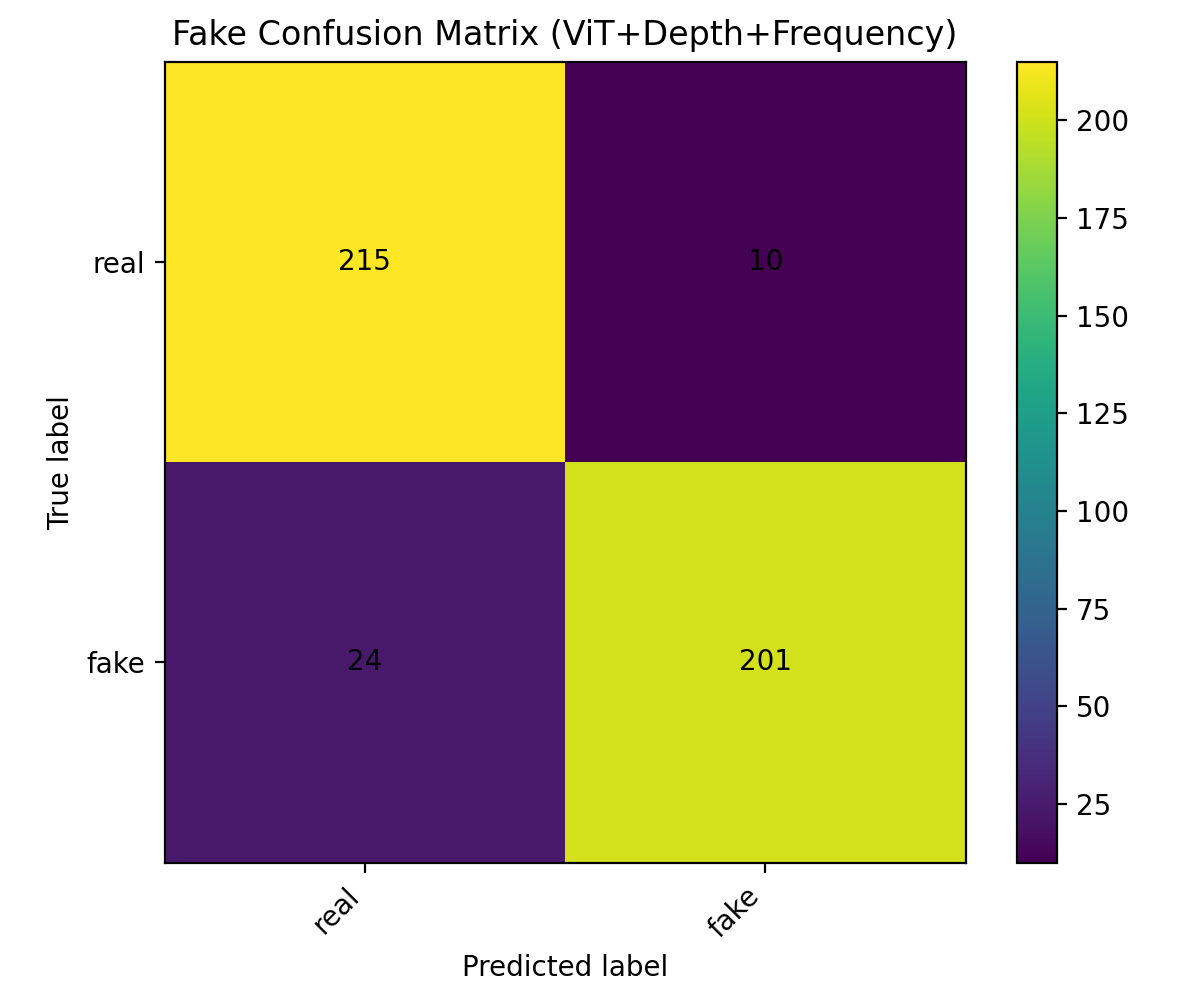


Transformation confusion matrix


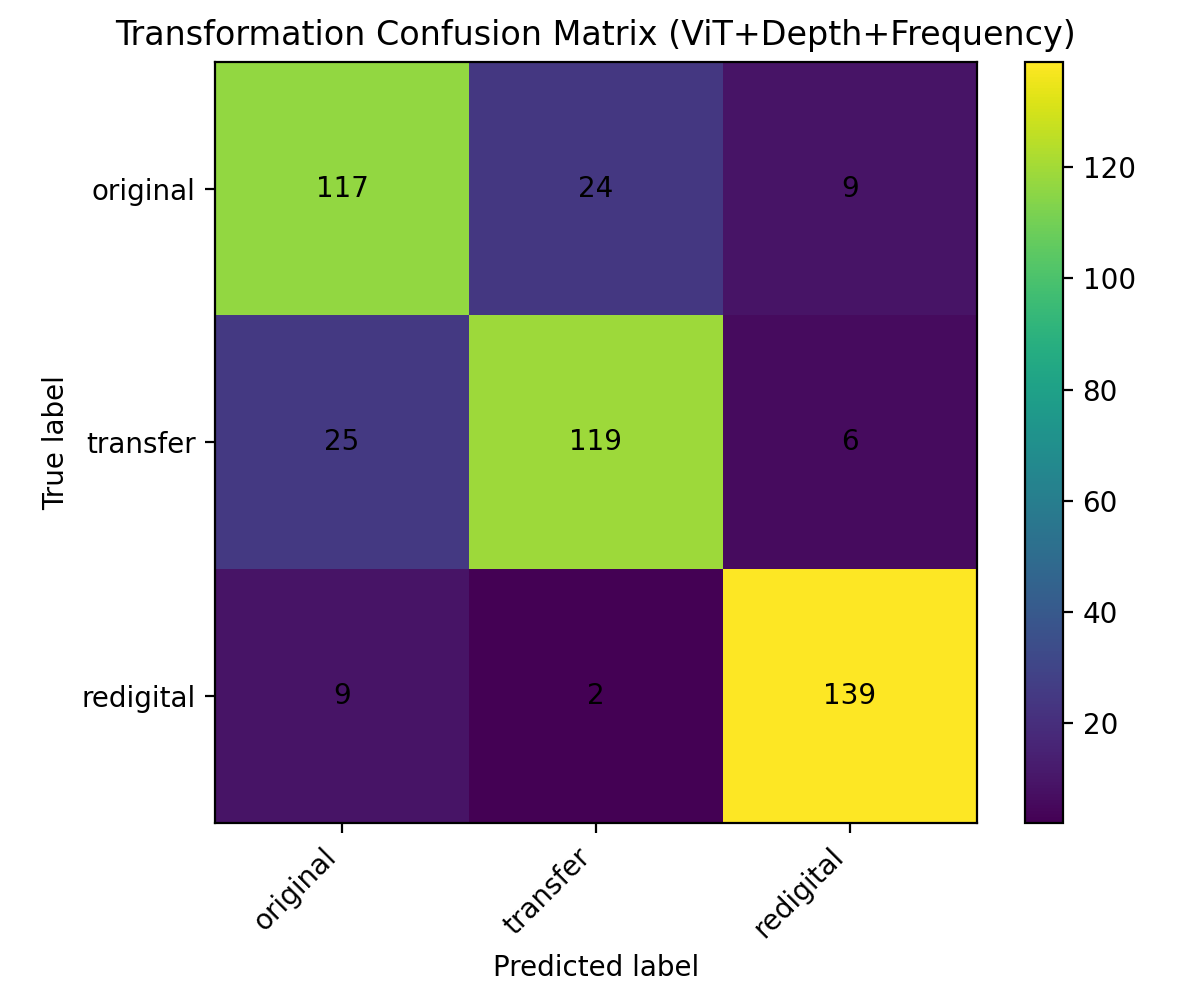

In [ ]:
show_evaluation_outputs("results/vit_depth_freq_multitask_1_2")

##Comparison

[SKIP] results/rgb_fake/metrics.json
[SKIP] results/rgb_transform/metrics.json
[SKIP] results/rgb_multitask_1_1/metrics.json
[SKIP] results/rgb_multitask_1_2/metrics.json
[SKIP] results/rgb_multitask_2_1/metrics.json
[SKIP] results/rgb_multitask_learned_weights/metrics.json
[SKIP] results/depth_frequency_1_1/metrics.json
[SKIP] results/depth_frequency_1_2/metrics.json
[SKIP] results/vit_rgb_multitask_1_1/metrics.json
[SKIP] results/vit_rgb_multitask_1_2/metrics.json
[SKIP] results/vit_rgb_multitask_learned/metrics.json
[SKIP] results/vit_depth_freq_multitask_1_1/metrics.json
=== Tabella comparativa ResNet vs ViT ===


,model,fake_accuracy,transform_accuracy,fake_f1_macro,transform_f1_macro
0,ViT D+F 1-2,0.9244,0.8333,0.9244,0.8329


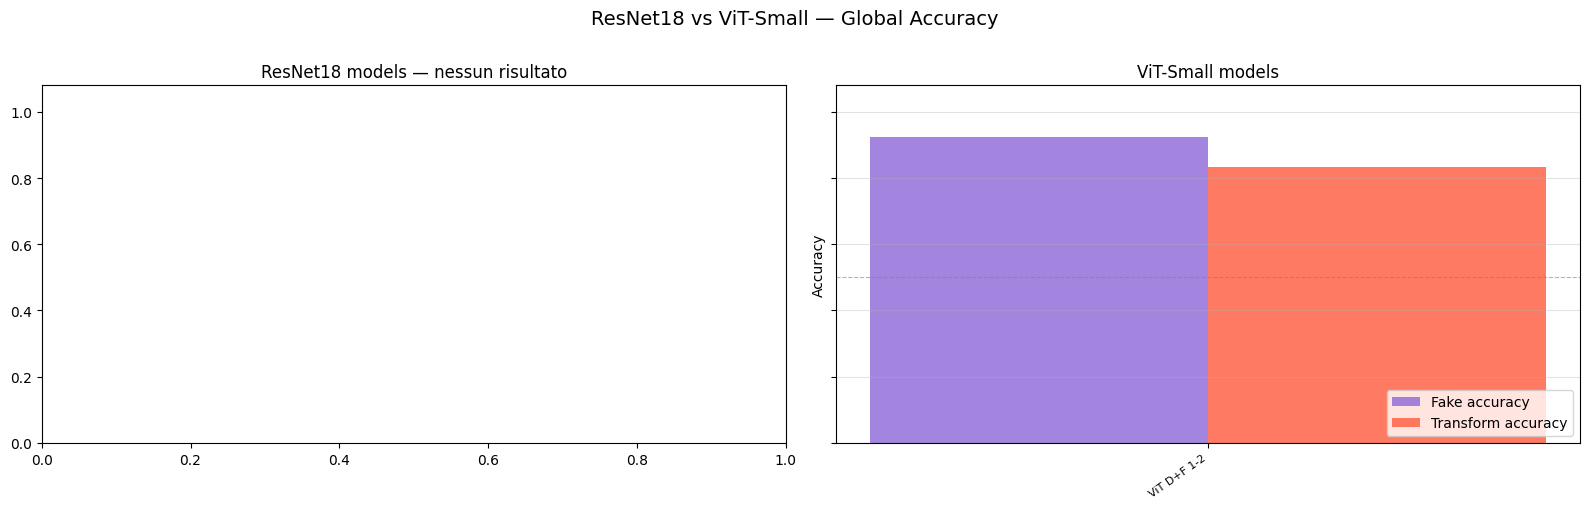

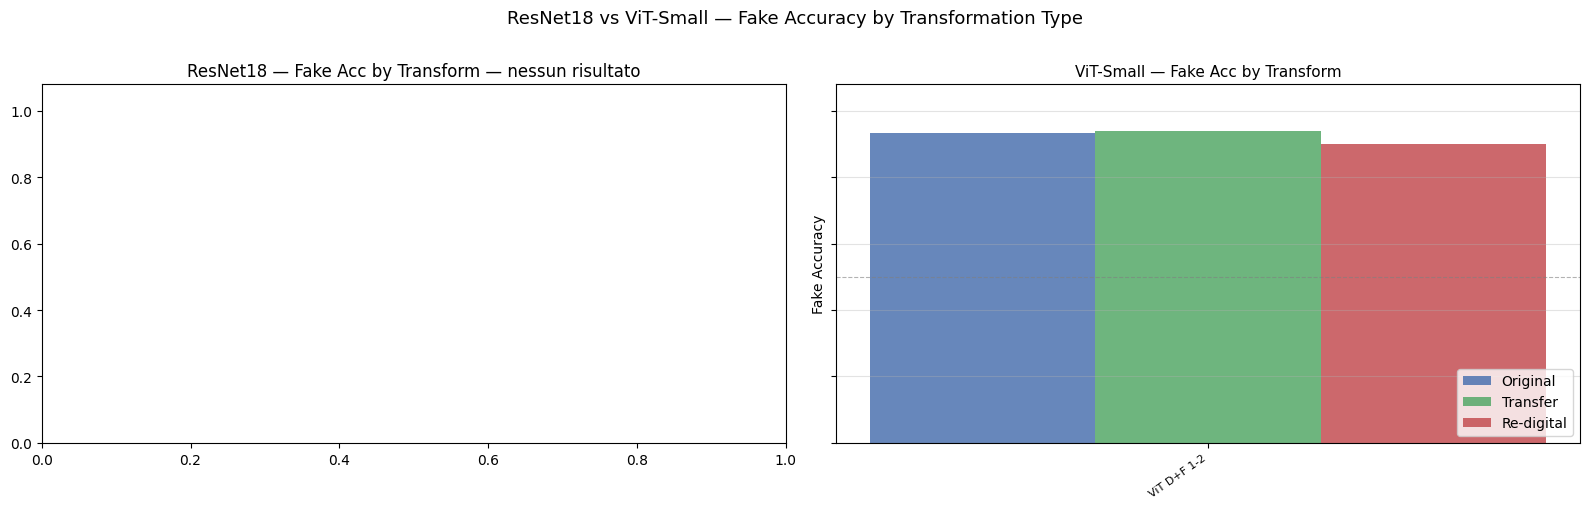


=== Miglior modello per gruppo ===
ResNet18: nessun risultato disponibile
ViT-Small: ViT D+F 1-2  →  fake=0.9244  transform=0.8333


In [ ]:
import sys
sys.path.insert(0, str(REPO_DIR / "src"))

from utilities import compare_resnet_vs_vit

RESNET_RESULTS = {
    "ResNet fake-only":         "results/rgb_fake/metrics.json",
    "ResNet transform-only":    "results/rgb_transform/metrics.json",
    "ResNet multitask 1-1":     "results/rgb_multitask_1_1/metrics.json",
    "ResNet multitask 1-2":     "results/rgb_multitask_1_2/metrics.json",
    "ResNet multitask 2-1":     "results/rgb_multitask_2_1/metrics.json",
    "ResNet multitask learned": "results/rgb_multitask_learned_weights/metrics.json",
    "ResNet D+F 1-1":           "results/depth_frequency_1_1/metrics.json",
    "ResNet D+F 1-2":           "results/depth_frequency_1_2/metrics.json",
}

VIT_RESULTS = {
    "ViT multitask 1-1":        "results/vit_rgb_multitask_1_1/metrics.json",
    "ViT multitask 1-2":        "results/vit_rgb_multitask_1_2/metrics.json",
    "ViT multitask learned":    "results/vit_rgb_multitask_learned/metrics.json",
    "ViT D+F 1-1":              "results/vit_depth_freq_multitask_1_1/metrics.json",
    "ViT D+F 1-2":              "results/vit_depth_freq_multitask_1_2/metrics.json",
}

compare_resnet_vs_vit(RESNET_RESULTS, VIT_RESULTS)

#tabelle in caso

In [ ]:
ABLATION_OUTPUT_DIR = Path("results/ablation_study")
ABLATION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

depth_comparison_df.to_csv(
    ABLATION_OUTPUT_DIR / "depth_vs_depth_edge_comparison.csv",
    index=False,
)

depth_frequency_comparison_df.to_csv(
    ABLATION_OUTPUT_DIR / "depth_frequency_simple_vs_gated_comparison.csv",
    index=False,
)

print("Saved ablation tables in:", ABLATION_OUTPUT_DIR)